<a href="https://colab.research.google.com/github/JuanZapa7a/Medical-Image-Processing/blob/main/PIM_Challenge/PIM_Challenge_Solucion_Ganadora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UPCT Medical Image Segmentation Challenge 2026-27
## Práctica 6

**Asignatura:** Procesado de Imágenes Médicas (521104007)

**Profesor:** Juan Zapata

> **Cómo funciona esta serie de notebooks:** cada semana se libera un notebook nuevo (Práctica 6 a 10) con el contenido de esa sesión. **Este primer notebook (P6) es la base de tu proyecto**: complétalo, y a partir de la próxima semana copia las celdas nuevas de cada práctica y pégalas **al final de este mismo notebook** — no empieces uno nuevo cada semana ni pegues de nuevo prácticas ya hechas. Al llegar a la P10 tendrás tu propio notebook completo con las 5 prácticas: ese es el que entregarás en el aula virtual.
>
> Cada práctica se abre en un **runtime nuevo** de Colab, así que cada día tendrás que ejecutar todas las celdas de tu notebook desde el principio (incluidas las de semanas anteriores) — no hace falta rehacer nada: los checkpoints en Drive detectan que ya existen y se cargan directamente en vez de reentrenar.

## Guía de Sesiones (2 horas por sesión)
| Práctica | Fechas (Grupo A / B) | Objetivo de la Sesión | Checkpoint Visual |
|----------|----------------------|-----------------------|-------------------|
| ▶ **P6** | 28 Oct - 2 Nov | EDA, Dataset y formato RLE | 6 imágenes con máscaras + RLE OK |
| **P7** | 9-11 Nov | Baseline U-Net y 1ª Submission | Gráficas de Loss + Submission Kaggle |
| **P8** | 16-18 Nov | Data Augmentation y mejora | Comparativa Baseline vs Augmented |
| **P9** | 23-25 Nov | Inferencia, Threshold y Errores | 5 imágenes normales + 2 casos de error |
| **P10** | 30 Nov-2 Dic | TTA, Submission Final y Defensa | Mejor Dice Score + Defensa Oral |

> **Regla de Oro:** Según el Art. 7.5 del Reglamento de Evaluación UPCT, la asistencia y validación del Checkpoint en el aula es obligatoria para superar la práctica.


## Descargar el Dataset de la Competición

El dataset de este reto es **privado** y solo está disponible dentro de la competición en Kaggle.

### Instrucciones:
1. **Acepta la invitación** al reto que te llegó por email (o accede directamente):
   [UPCT Medical Image Segmentation Challenge](https://www.kaggle.com/competitions/upct-medical-image-segmentation-challenge-2026-27)

2. Dentro de la competición, ve a la pestaña **"Data"** (en el menú superior).

3. Haz clic en **"Download All"** o descarga el archivo **`upct-medical-image-segmentation-challenge-2026-27.zip`** (aprox. 150 MB).

4. **Sube el archivo ZIP** a tu Google Drive en una carpeta llamada **`PIM_Challenge`**:
   - Entra en [Google Drive](https://drive.google.com)
   - Crea la carpeta `PIM_Challenge` (si no existe)
   - Sube el ZIP ahí

> **IMPORTANTE:**
> - **NO cambies el nombre del archivo ZIP** (debe mantener el nombre original)
> - **NO descomprimas el ZIP** antes de subirlo (lo haremos desde Colab)
> - Si no puedes acceder a la competición, contacta con el profesor: juan.zapata@upct.es

## Estructura del dataset

Una vez descomprimido, el dataset tendrá esta estructura:


In [1]:
# ============================================================
# VERIFICACIÓN Y EXPLORACIÓN DEL DATASET DESCARGADO
# ============================================================

# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Instalar tree para visualizar carpetas
!apt-get install -y tree > /dev/null 2>&1

# 3. Localizar el ZIP en PIM_Challenge
import os
import zipfile
import shutil
from pathlib import Path

DRIVE_FOLDER = '/content/drive/MyDrive/PIM_Challenge'
EXTRACT_DIR = Path('/content/PIM_Challenge_dataset')

print(f"\n Buscando dataset en: {DRIVE_FOLDER}\n")

# Listar contenido de la carpeta
if os.path.exists(DRIVE_FOLDER):
    print(" Contenido de PIM_Challenge:")
    for f in os.listdir(DRIVE_FOLDER):
        size = os.path.getsize(os.path.join(DRIVE_FOLDER, f)) / (1024*1024)
        print(f"   - {f} ({size:.1f} MB)")
else:
    print(f" La carpeta {DRIVE_FOLDER} no existe")
    raise FileNotFoundError(DRIVE_FOLDER)

# Buscar el ZIP
zip_files = [f for f in os.listdir(DRIVE_FOLDER) if f.endswith('.zip')]

if not zip_files:
    print("\n No hay ningún archivo ZIP en PIM_Challenge")
    print(" Sube el ZIP que descargaste de Kaggle a esa carpeta")
    raise FileNotFoundError("No hay ZIP en PIM_Challenge")

ZIP_PATH = os.path.join(DRIVE_FOLDER, zip_files[0])
print(f"\n ZIP encontrado: {zip_files[0]}")

# 4. Descomprimir
if not EXTRACT_DIR.exists():
    print(f"\n Descomprimiendo {zip_files[0]}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content')
    print("Descompresión completada.\n")
else:
    print(f"\nDataset ya descomprimido en {EXTRACT_DIR}\n")

# 5. Reorganizar si es necesario (Kaggle a veces descomprime en /content/ directamente)
print("Verificando estructura del dataset...")

if not (EXTRACT_DIR / 'train').exists() and Path('/content/train').exists():
    print(" Dataset descomprimido en /content/. Reorganizando...")

    if not EXTRACT_DIR.exists():
        EXTRACT_DIR.mkdir()

    items_to_move = ['train', 'test', 'sample_submission.csv']
    for item in items_to_move:
        src = Path(f'/content/{item}')
        dst = EXTRACT_DIR / item

        if src.exists():
            if dst.exists():
                if dst.is_dir():
                    shutil.rmtree(dst)
                else:
                    dst.unlink()

            shutil.move(str(src), str(dst))
            print(f"    Movido: {item}")
        else:
            print(f"    No encontrado: {item}")

    print(" Reorganización completada.\n")
elif (EXTRACT_DIR / 'train').exists():
    print(" Estructura correcta detectada.\n")
else:
    print(" No se encuentra la estructura esperada. Buscando carpetas train/test...\n")

# 6. Mostrar estructura del dataset
print("="*60)
print(" ESTRUCTURA DEL DATASET")
print("="*60)
!tree -L 3 /content/PIM_Challenge_dataset --dirsfirst

# 7. Estadísticas detalladas
print("\n" + "="*60)
print(" ESTADÍSTICAS DETALLADAS")
print("="*60)

import glob

train_imgs = glob.glob(f'{EXTRACT_DIR}/train/images/*.png')
train_masks = glob.glob(f'{EXTRACT_DIR}/train/masks/*.png')
test_imgs = glob.glob(f'{EXTRACT_DIR}/test/images/*.png')

# Contar por clase
train_benign = len([f for f in train_imgs if 'benign' in f])
train_malignant = len([f for f in train_imgs if 'malignant' in f])
train_normal = len([f for f in train_imgs if 'normal' in f])

test_benign = len([f for f in test_imgs if 'benign' in f])
test_malignant = len([f for f in test_imgs if 'malignant' in f])
test_normal = len([f for f in test_imgs if 'normal' in f])

print(f"\n TRAIN SET: {len(train_imgs)} imágenes")
print(f"   ├─ Benign:     {train_benign:3d} imágenes")
print(f"   ├─ Malignant:  {train_malignant:3d} imágenes")
print(f"   └─ Normal:     {train_normal:3d} imágenes")
print(f"    Máscaras:   {len(train_masks)} archivos")

print(f"\n TEST SET: {len(test_imgs)} imágenes (SIN máscaras)")
print(f"   ├─ Benign:     {test_benign:3d} imágenes")
print(f"   ├─ Malignant:  {test_malignant:3d} imágenes")
print(f"   └─ Normal:     {test_normal:3d} imágenes")

has_csv = os.path.exists(f'{EXTRACT_DIR}/sample_submission.csv')
print(f"\nsample_submission.csv: {' Existe' if has_csv else ' No existe'}")

# 8. Verificación de integridad
print("\n" + "="*60)
print(" VERIFICACIÓN DE INTEGRIDAD")
print("="*60)

checks = [
    (len(train_imgs) == 546, f"Train images: {len(train_imgs)}/546"),
    (len(train_masks) == 546, f"Train masks: {len(train_masks)}/546"),
    (len(test_imgs) == 234, f"Test images: {len(test_imgs)}/234"),
    (has_csv, "sample_submission.csv existe"),
]

all_ok = True
for ok, desc in checks:
    print(f"   {'OK' if ok else 'noOK'} {desc}")
    if not ok:
        all_ok = False

# Verificación final
if all_ok:
    print("\n ¡Dataset correcto y listo para trabajar!")
else:
    print("\n Hay problemas en el dataset. Revisa los archivos.")

Mounted at /content/drive

 Buscando dataset en: /content/drive/MyDrive/PIM_Challenge

 Contenido de PIM_Challenge:
   - upct-medical-image-segmentation-challenge-2026-27.zip (194.7 MB)
   - checkpoints (0.0 MB)

 ZIP encontrado: upct-medical-image-segmentation-challenge-2026-27.zip

 Descomprimiendo upct-medical-image-segmentation-challenge-2026-27.zip...
Descompresión completada.

Verificando estructura del dataset...
 Dataset descomprimido en /content/. Reorganizando...
    Movido: train
    Movido: test
    Movido: sample_submission.csv
 Reorganización completada.

 ESTRUCTURA DEL DATASET
/content/PIM_Challenge_dataset
├── test
│   └── images
│       ├── benign (102).png
│       ├── benign (110).png
│       ├── benign (113).png
│       ├── benign (116).png
│       ├── benign (11).png
│       ├── benign (124).png
│       ├── benign (126).png
│       ├── benign (128).png
│       ├── benign (12).png
│       ├── benign (131).png
│       ├── benign (133).png
│       ├── benign (138).png

## Configuración global: ¿reentrenar siempre o reutilizar checkpoints?
- **`FORZAR_REENTRENAMIENTO = True`** → **siempre entrena desde cero** (modo observación):
  se ignoran los checkpoints de Drive y se ve el entrenamiento completo de cada práctica.
  **Recomendado para el profesor** al revisar el trabajo (en su Drive no hay checkpoints).
- **`FORZAR_REENTRENAMIENTO = False`** → el alumno **reutiliza los checkpoints** guardados en
  Drive (`PIM_Challenge/checkpoints`) entre sesiones, como prevé la P7 (no reentrenar cada día).

In [2]:
# ============================================================
# CONFIGURACIÓN GLOBAL
# ============================================================
FORZAR_REENTRENAMIENTO = True   # True: reentrenar siempre (observar todo el proceso)
                                # False: reutilizar checkpoints de Drive entre sesiones

print(f"FORZAR_REENTRENAMIENTO = {FORZAR_REENTRENAMIENTO} "
      f"-> {'reentrenando siempre (modo observación)' if FORZAR_REENTRENAMIENTO else 'reutilizando checkpoints de Drive'}")

FORZAR_REENTRENAMIENTO = True -> reentrenando siempre (modo observación)


# PRÁCTICA 6: Exploración del Dataset y Formato RLE
## Sesión única (28 Oct - miércoles - y 2 Nov - lunes -)

### Objetivos de la sesión:
1. Entender la estructura del dataset BUSI (benign, malignant, normal)
2. Visualizar imágenes y máscaras de segmentación
3. Comprender el formato RLE (Run-Length Encoding) para Kaggle
4. Crear el DataLoader para entrenamiento

### Contexto clínico
El dataset BUSI contiene 780 imágenes de ultrasonido mamario:
- **Benign (437)**: Lesiones no cancerosas
- **Malignant (210)**: Lesiones cancerosas
- **Normal (133)**: Tejido sano (sin lesión)

**Reto clínico**: El modelo debe saber decir "no hay tumor" en las imágenes normales.

> **CHECKPOINT P6:** Mostrar al profesor la visualización de imágenes con sus máscaras superpuestas y la verificación de que tus funciones `mask_to_rle`/`rle_to_mask` reconstruyen la máscara original correctamente.

### Tiempo estimado: 2 horas

## Bloque 6.1: Segmentación Semántica en Imágenes Médicas
### Clasificación vs Detección vs Segmentación

| Tarea | Pregunta que responde | Salida |
|-------|----------------------|--------|
| **Clasificación** | ¿Hay tumor? | Etiqueta: "benigno" / "maligno" |
| **Detección** | ¿Dónde está el tumor? | Bounding box |
| **Segmentación** | ¿Qué píxeles son tumor? | Máscara píxel a píxel |

### ¿Por qué segmentación y no clasificación?
- En medicina, el **tamaño y forma** del tumor importan (estadiaje)
- Permite calcular **volumen**, **bordes irregulares**, **invasión**
- Es la base de la **radiómica** y el diagnóstico asistido

### El reto específico: Ultrasonido mamario (BUS)
- Imágenes **ruidosas** y de **bajo contraste**
- Tumores **pequeños** (a veces < 5% de la imagen)
- Artefactos: sombras acústicas, reverberaciones
- **Clase "normal"**: el modelo debe aprender a NO detectar nada

## Tarea 6.1: Carga y estructuración del Dataset
Antes de entrenar ningún modelo, necesitamos organizar la información en memoria.
Vamos a usar la librería **Pandas** para crear un DataFrame que actúe como índice de nuestro dataset, relacionando cada imagen con su clase y su máscara.

### Instrucciones:
1. Define la ruta base del dataset: `/content/PIM_Challenge_dataset`.
2. Recorre la carpeta `train/images` buscando todas las imágenes `.png`.
3. Para cada imagen, extrae su **clase** (`benign`, `malignant` o `normal`) basándote en el nombre de directorio.
4. Busca la ruta de su máscara correspondiente en la carpeta `train/masks`. *(Pista: el nombre de la máscara suele ser el mismo que la imagen pero añadiendo `_mask` al final).*
5. Guarda toda esta información en un **DataFrame de Pandas** con las columnas: `class`, `image_path`, `mask_path` y `filename`.
6. Muestra por pantalla el número total de imágenes y la distribución de clases (cuántas hay de cada tipo: benign, malignat y normal ).

> **Librerías recomendadas:** `pandas`, `pathlib`, `os`.


In [3]:
# ============================================================
# TAREA 6.1: CARGA DEL DATASET EN PANDAS  ✔ SOLUCIÓN
# ============================================================
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('/content/PIM_Challenge_dataset')

# Auto-detección de la raíz real del dataset (el ZIP de Kaggle puede extraerse
# con prefijo BUSI_public/ o directamente en /content)
for _root in [DATA_DIR, Path('/content/BUSI_public'), Path('/content/pim_data/BUSI_public'), Path('/content')]:
    if (_root / 'train' / 'images').exists() and (_root / 'test' / 'images').exists():
        DATA_DIR = _root
        break
print(f"Raíz del dataset: {DATA_DIR}")

data = []
for cls in ['benign', 'malignant', 'normal']:
    img_dir = DATA_DIR / 'train' / 'images'
    mask_dir = DATA_DIR / 'train' / 'masks'

    for img_path in img_dir.glob(f'*{cls}*.png'):
        mask_path = mask_dir / f"{img_path.stem}_mask.png"
        data.append({
            'class': cls,
            'image_path': str(img_path),
            'mask_path': str(mask_path) if mask_path.exists() else None,
            'filename': img_path.name,
        })

df_train = pd.DataFrame(data)

print(f"Dataset cargado: {len(df_train)} imágenes de entrenamiento.")
print("\n Distribución de clases en Train:")
print(df_train['class'].value_counts())


Raíz del dataset: /content/PIM_Challenge_dataset
Dataset cargado: 546 imágenes de entrenamiento.

 Distribución de clases en Train:
class
benign       306
malignant    147
normal        93
Name: count, dtype: int64


## Bloque 6.2: El Dataset BUSI (Breast Ultrasound Images)
### Origen y composición
- Publicado por **Al-Dhabyani et al. (2020)**
- 780 imágenes de ultrasonido mamario
- 3 clases:
  - **Benign (437)**: fibroadenomas, quistes...
  - **Malignant (210)**: carcinomas
  - **Normal (133)**: tejido sano

### El desbalance de clases

>  **Pregunta para pensar:** ¿Por qué hay más imágenes benignas que malignas en la realidad clínica?

### El "Reto Oculto": las imágenes normales
La mayoría de competiciones de segmentación asumen que **todas las imágenes tienen el objeto a segmentar**. En este reto:
- Las imágenes **normal** tienen máscara **vacía** (toda negra)
- Si tu modelo pinta un tumor donde no lo hay → **FALSO POSITIVO**
- Consecuencia clínica: biopsia innecesaria, ansiedad, coste sanitario

### Métricas: ¿por qué no usamos Accuracy?
Imagina un modelo que dice "no hay tumor" en TODAS las imágenes:
- Accuracy: ~85% (porque el 85% de los píxeles son fondo)
- Dice Score: **0** (no ha detectado ningún tumor)

Por eso en segmentación médica usamos **Dice Score** o **IoU**.

> **Pregunta para pensar:** "Si tuvierais que diagnosticar a una paciente, ¿qué os preocuparía más: un falso positivo o un falso negativo? ¿Por qué?"


## Tarea 6.2: Visualización y el "Reto Clínico Oculto"
No podemos confiar en los datos a ciegas. Vamos a visualizar los datos para asegurarnos de que las máscaras están alineadas con las imágenes y entender la dificultad clínica del reto.

### Instrucciones:
1. Selecciona **1 imagen aleatoria de cada clase** (benign, malignant, normal) de tu DataFrame.
2. Crea una figura de **3 filas x 3 columnas** usando `matplotlib` (una fila por clase).
3. Para cada imagen, carga y muestra en las 3 columnas:
   * **Columna 1 (Original):** La imagen en RGB. *(Recuerda que `cv2.imread` la lee en BGR, tendrás que convertirla).*
   * **Columna 2 (Máscara Real):** La máscara en escala de grises.
   * **Columna 3 (Overlay):** Copia la imagen original y **pinta de ROJO `[255, 0, 0]`** los píxeles donde la máscara indica que hay tumor.
4. Analiza las imágenes de la clase **"normal"**. Escribe un `print()` al final explicando:
   * ¿Qué ves en sus máscaras?
   * ¿Qué pasaría clínicamente si tu modelo de IA predice un tumor (píxeles rojos) en una de estas imágenes?

> **CHECKPOINT P6.1:** Cuando tengas la figura 3x3 generada, llama al profesor para que valide tu visualización y tu conclusión clínica.

> **Librerías recomendadas:** `cv2`, `matplotlib.pyplot`, `numpy`.

/tmp/ipykernel_354/1731809008.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = df_train.groupby('class').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)


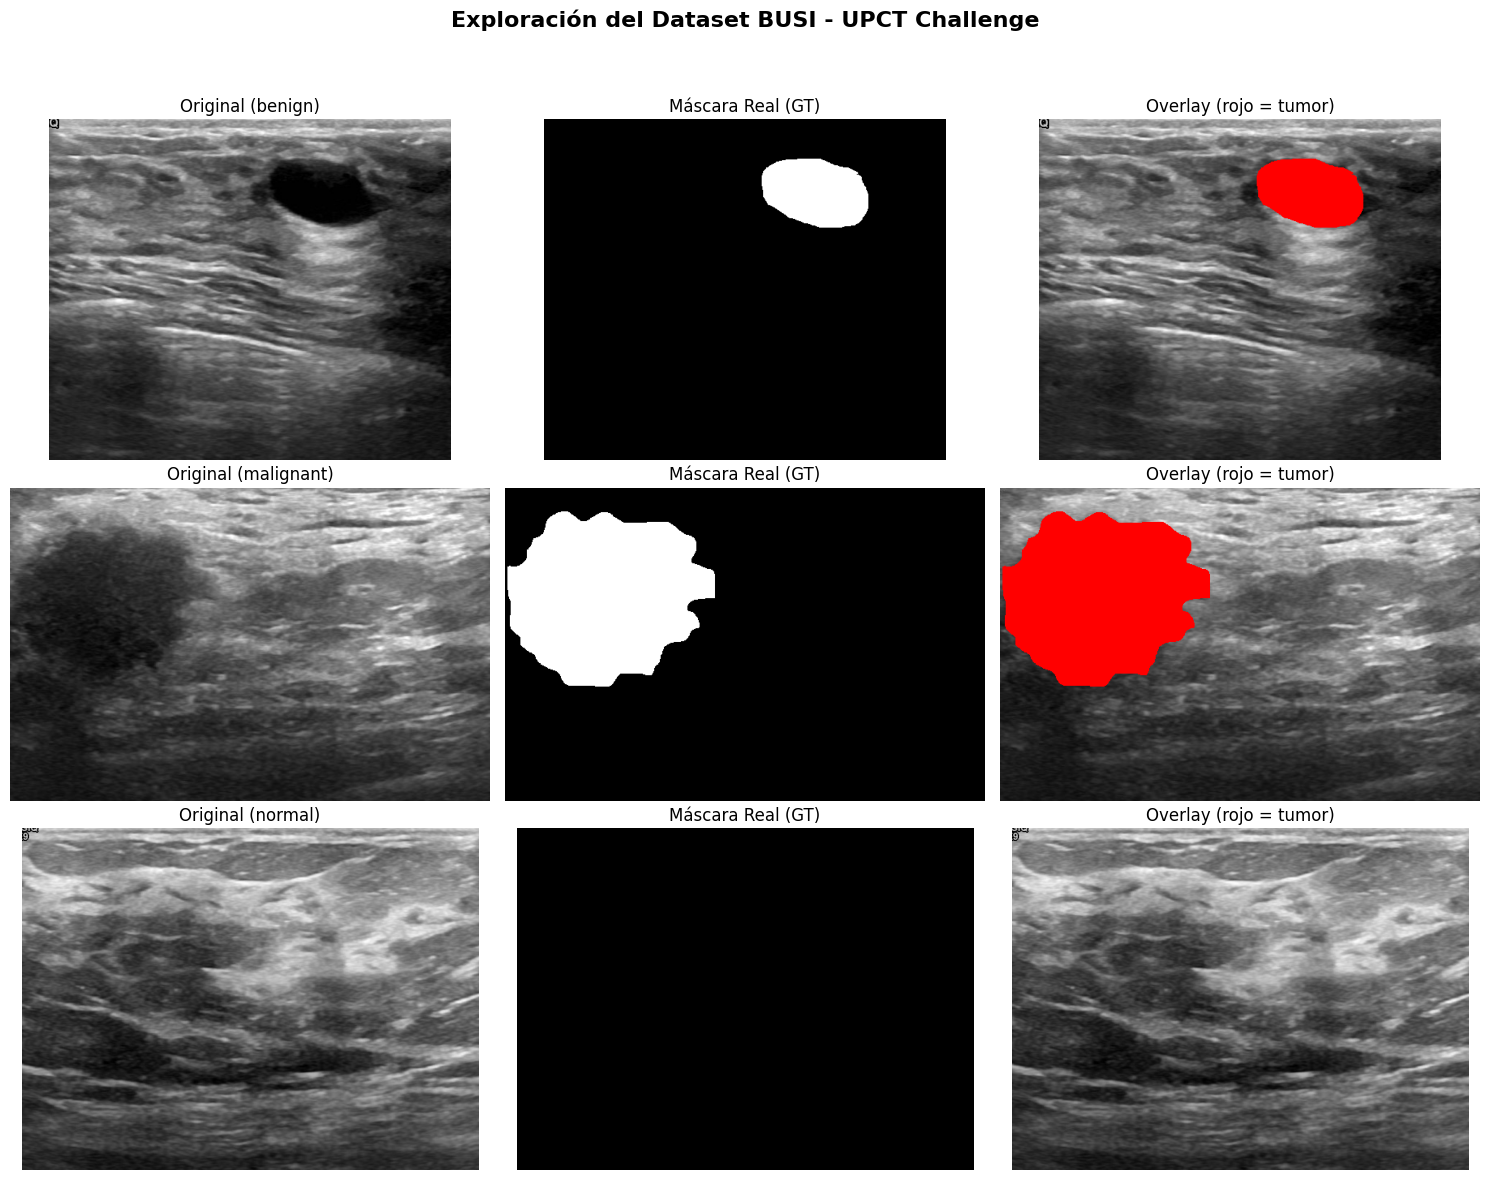

Imágenes 'normal' con máscara totalmente negra (vacía): 93/93

 CONCLUSIÓN CLÍNICA:
Si tu modelo predice un tumor en una imagen 'normal', estará cometiendo un FALSO POSITIVO.
En medicina, esto puede llevar a biopsias innecesarias y ansiedad en la paciente.
Tu modelo debe aprender a NO segmentar nada cuando no hay lesión.

=== CHECKPOINT P6.1 ✔ (figura 3x3 + conclusión clínica) ===


In [4]:
# ============================================================
# TAREA 6.2: VISUALIZACIÓN DE EJEMPLOS  ✔ SOLUCIÓN
# ============================================================
samples = df_train.groupby('class').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Exploración del Dataset BUSI - UPCT Challenge', fontsize=16, fontweight='bold')

for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    if row['mask_path'] and Path(row['mask_path']).exists():
        mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Original ({row['class']})", fontsize=12); axes[i, 0].axis('off')
    axes[i, 1].imshow(mask, cmap='gray'); axes[i, 1].set_title("Máscara Real (GT)", fontsize=12); axes[i, 1].axis('off')
    overlay = img.copy()
    if mask.max() > 0:
        overlay[mask > 0] = [255, 0, 0]
    axes[i, 2].imshow(overlay); axes[i, 2].set_title("Overlay (rojo = tumor)", fontsize=12); axes[i, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Análisis del reto oculto: máscaras de las imágenes 'normal'
normal_samples = df_train[df_train['class'] == 'normal']
empty_masks = 0
for _, row in normal_samples.iterrows():
    if row['mask_path'] and Path(row['mask_path']).exists():
        if cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE).max() == 0:
            empty_masks += 1

print(f"Imágenes 'normal' con máscara totalmente negra (vacía): {empty_masks}/{len(normal_samples)}")
print("\n CONCLUSIÓN CLÍNICA:")
print("Si tu modelo predice un tumor en una imagen 'normal', estará cometiendo un FALSO POSITIVO.")
print("En medicina, esto puede llevar a biopsias innecesarias y ansiedad en la paciente.")
print("Tu modelo debe aprender a NO segmentar nada cuando no hay lesión.")
print("\n=== CHECKPOINT P6.1 ✔ (figura 3x3 + conclusión clínica) ===")


## Bloque 6.3: Formatos de Submission y Métricas
### ¿Por qué RLE y no PNG?
Kaggle necesita un formato **texto** para:
1. **Compresión**: una máscara de 512x512 = 262,144 píxeles → en RLE pueden ser solo 20 números
2. **Validación automática**: fácil de parsear y comparar
3. **Múltiples objetos**: se pueden codificar varios tumores en una imagen

### Métricas clave en Kaggle

**Dice Score (F1 Score):**
$$Dice = \frac{2 \cdot |A \cap B|}{|A| + |B|}$$

**IoU (Intersection over Union):**
$$IoU = \frac{|A \cap B|}{|A \cup B|}$$

**Relación:** $Dice = \frac{2 \cdot IoU}{1 + IoU}$

| Dice Score | Interpretación clínica |
|------------|----------------------|
| 0.9 - 1.0 | Segmentación excelente |
| 0.7 - 0.9 | Buena (típico en competiciones) |
| 0.5 - 0.7 | Aceptable, mejorable |
| < 0.5 | Modelo no útil clínicamente |

### Calcular manualmente:
"Calculad a mano el Dice de este ejemplo:"

    Predicción: 100 píxeles de tumor
    Ground truth: 100 píxeles de tumor
    Intersección: 80 píxeles
    Respuesta: Dice = 2·80/(100+100) = 0.80

## Tarea 6.3: El Formato RLE (Run-Length Encoding)
Kaggle no acepta máscaras como imágenes PNG para las submissions. En su lugar, exige que las máscaras se envíen en formato de texto usando **Run-Length Encoding (RLE)**.

### ¿Qué es RLE?
Es un método de compresión muy simple: en lugar de guardar cada píxel, guardamos **secuencias de píxeles iguales**.

**Ejemplo:**
Imagina una máscara de 5x5 (25 píxeles) donde los píxeles del centro son tumor (1) y el resto es fondo (0):

0 0 0 0 0

0 1 1 1 0

0 1 1 1 0

0 1 1 1 0

0 0 0 0 0


En formato RLE, esto se expresa como:
`"7 3 12 3 17 3"`

**¿Qué significa?**
- `7 3` → Empezando en el píxel 7, hay 3 píxeles de tumor
- `12 3` → Empezando en el píxel 12, hay 3 píxeles de tumor
- `17 3` → Empezando en el píxel 17, hay 3 píxeles de tumor

> **IMPORTANTE:** Kaggle lee las imágenes **por columnas** (de arriba a abajo, luego siguiente columna), no por filas. Y los índices empiezan en **1**, no en 0.

### Instrucciones:
1. Implementa la función `mask_to_rle(mask)` que:
   - Reciba una máscara binaria (numpy array de 0s y 1s)
   - La aplane por columnas (usa `.T.flatten()`)
   - Detecte los cambios de 0 a 1 y de 1 a 0
   - Devuelva un string con el formato RLE (pares de números separados por espacios)

2. Implementa la función `rle_to_mask(rle_string, height, width)` que:
   - Reciba un string RLE y las dimensiones de la imagen
   - Reconstruya la máscara binaria original
   - Devuelva un numpy array de la forma `(height, width)`

3. **Prueba tus funciones:**
   - Crea una máscara de prueba (puedes usar una máscara real del dataset o crear una artificial)
   - Conviértela a RLE con `mask_to_rle()`
   - Reconstrúyela con `rle_to_mask()`
   - Verifica que la máscara original y la reconstruida son **idénticas** (usa `np.array_equal()`)

4. **Visualiza el resultado:**
   - Muestra 3 imágenes: máscara original, máscara reconstruida, y la diferencia (debe ser toda negra si funciona bien)

> **Pista:** Para detectar los cambios en la secuencia de píxeles, puedes usar `np.where(pixels[1:] != pixels[:-1])`.

> **CHECKPOINT P6.2:** Muestra al profesor que tus funciones RLE funcionan correctamente (la diferencia entre máscara original y reconstruida debe ser cero).

Máscara original: forma (468, 557), píxeles de tumor: 4498
RLE encoded (primeros 50 caracteres): 87153 15 87619 20 88085 26 88552 29 89019 33 89486...
Máscara reconstruida: forma (468, 557), píxeles de tumor: 4498

¿Son idénticas? True


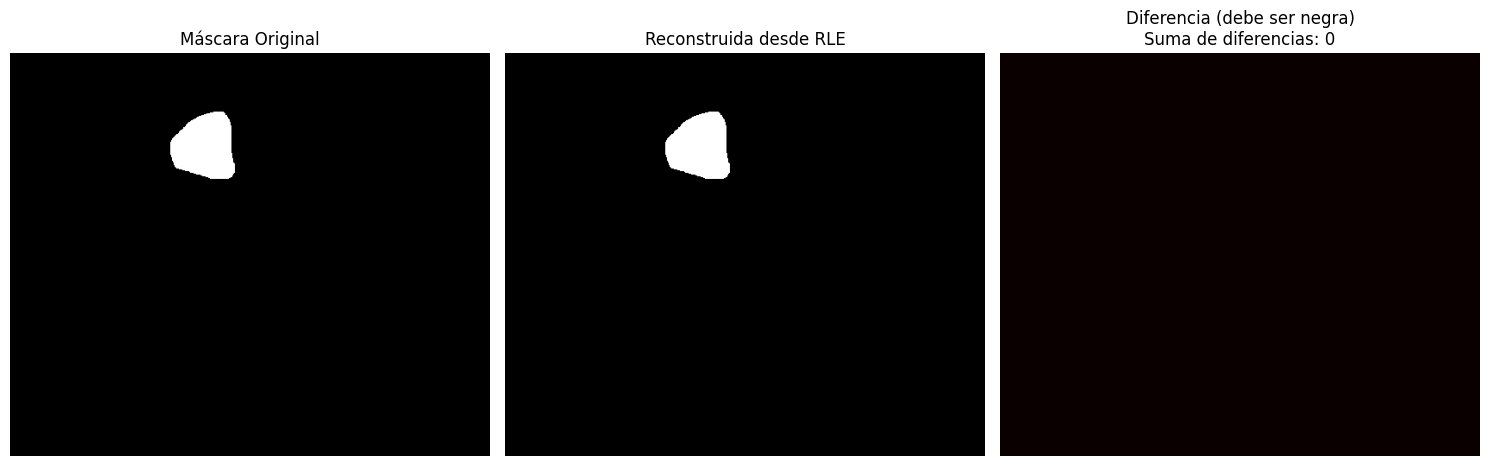


¡Funciona perfectamente! Tus funciones RLE son correctas.
=== CHECKPOINT P6.2 ✔ (reconstrucción idéntica, diferencia = 0) ===


In [5]:
# ============================================================
# TAREA 6.3: IMPLEMENTACIÓN DE RLE  ✔ SOLUCIÓN
# ============================================================

import numpy as np

def mask_to_rle(mask):
    """
    Convierte una máscara binaria a formato RLE.

    Args:
        mask: numpy array binario (0s y 1s) de forma (height, width)

    Returns:
        str: string con el formato RLE (pares de números separados por espacios)
    """
    pixels = mask.T.flatten()                          # aplanar POR COLUMNAS
    pixels_padded = np.concatenate([[0], pixels, [0]])
    changes = np.where(pixels_padded[1:] != pixels_padded[:-1])[0]
    rle_parts = []
    for i in range(0, len(changes), 2):
        start = changes[i]                             # inicio del run (0-indexed)
        length = changes[i + 1] - changes[i]
        rle_parts.append(f"{start + 1} {length}")      # 1-indexed para Kaggle
    return " ".join(rle_parts)                         # máscara vacía -> ''


def rle_to_mask(rle_string, height, width):
    """
    Convierte un string RLE a una máscara binaria.

    Args:
        rle_string: string con formato RLE
        height: altura de la imagen
        width: ancho de la imagen

    Returns:
        numpy array binario de forma (height, width)
    """
    pixels = np.zeros(height * width, dtype=np.uint8)
    if rle_string and rle_string.strip():
        parts = rle_string.split()
        for i in range(0, len(parts), 2):
            start = int(parts[i]) - 1
            length = int(parts[i + 1])
            pixels[start:start + length] = 1
    return pixels.reshape((width, height)).T


# ============================================================
# PRUEBA DE LAS FUNCIONES (no modificar)
# ============================================================

# Cargar una máscara real del dataset
sample_mask_path = df_train[df_train['class'] == 'benign'].iloc[0]['mask_path']
original_mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)
original_mask_bin = (original_mask > 127).astype(np.uint8)

print(f"Máscara original: forma {original_mask_bin.shape}, píxeles de tumor: {original_mask_bin.sum()}")

# Convertir a RLE
rle_encoded = mask_to_rle(original_mask_bin)
print(f"RLE encoded (primeros 50 caracteres): {rle_encoded[:50]}...")

# Reconstruir desde RLE
reconstructed_mask = rle_to_mask(rle_encoded, original_mask_bin.shape[0], original_mask_bin.shape[1])
print(f"Máscara reconstruida: forma {reconstructed_mask.shape}, píxeles de tumor: {reconstructed_mask.sum()}")

# Verificar que son idénticas
are_equal = np.array_equal(original_mask_bin, reconstructed_mask)
print(f"\n¿Son idénticas? {are_equal}")

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_mask_bin, cmap='gray')
axes[0].set_title("Máscara Original")
axes[0].axis('off')

axes[1].imshow(reconstructed_mask, cmap='gray')
axes[1].set_title("Reconstruida desde RLE")
axes[1].axis('off')

difference = np.abs(original_mask_bin.astype(int) - reconstructed_mask.astype(int))
axes[2].imshow(difference, cmap='hot')
axes[2].set_title(f"Diferencia (debe ser negra)\nSuma de diferencias: {difference.sum()}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

if are_equal:
    print("\n¡Funciona perfectamente! Tus funciones RLE son correctas.")
    print("=== CHECKPOINT P6.2 ✔ (reconstrucción idéntica, diferencia = 0) ===")
else:
    print("\nHay diferencias. Revisa tu implementación.")


# Práctica 7: Baseline Model (U-Net) y 1ª Submission
## Sesión única (9 Nov Grupo A / 11 Nov Grupo B)

### Objetivos de la sesión:
1. Crear un `Dataset` y `DataLoader` de PyTorch para cargar las imágenes y máscaras.
2. Definir la arquitectura **U-Net** y la función de pérdida (**Dice Loss + BCE**).
3. Entrenar el modelo durante unas pocas épocas (baseline).
4. Realizar la inferencia sobre el conjunto de test y generar el archivo `submission.csv`.

> **CHECKPOINT P7:** Mostrar al profesor las gráficas de pérdida (Loss) decreciendo y la captura de tu primera submission en el Leaderboard de Kaggle.

## Bloque 7.1: Dataset y DataLoader en PyTorch
### ¿Por qué no basta con una lista de arrays?

Hasta ahora habéis trabajado con imágenes cargadas "a mano" (un `cv2.imread` suelto, un bucle `for`). Para entrenar una red neuronal necesitáis algo más:

| Sin `Dataset`/`DataLoader` | Con `Dataset`/`DataLoader` |
|---|---|
| Bucle manual cargando todo en RAM | Carga **bajo demanda**, una muestra cada vez |
| Batches construidos a mano | Agrupa en **batches** automáticamente |
| Barajado manual (o ninguno) | `shuffle=True` reordena en cada época |
| Un solo proceso leyendo disco | `num_workers` carga en **paralelo** |

Con 546 imágenes esto no parece crítico, pero es el mismo patrón que usaréis con datasets de millones de imágenes: **PyTorch no cambia de API**, solo cambia el tamaño del dataset.

### La abstracción: dos piezas con responsabilidades distintas

```
DataFrame (índice)         Dataset                    DataLoader
class, image_path,   →    __getitem__(idx)    →      junta N muestras
mask_path, filename        devuelve 1 muestra          en un batch
                            (imagen, máscara)           (B, C, H, W)
```

| | `Dataset` | `DataLoader` |
|---|---|---|
| **Responde a** | "¿Cómo obtengo la muestra `i`?" | "¿Cómo agrupo y sirvo las muestras?" |
| **Métodos clave** | `__len__`, `__getitem__` | — (es un envoltorio) |
| **Tú decides** | Cómo cargar, preprocesar y devolver 1 muestra | `batch_size`, `shuffle`, `num_workers` |

> **Idea clave:** el `Dataset` no sabe nada de batches. Solo sabe devolver **una** muestra dado un índice. Toda la lógica de agrupar, barajar y paralelizar es responsabilidad del `DataLoader`.

### El reto de la segmentación: pares (imagen, máscara)

En clasificación, `__getitem__` devuelve `(imagen, etiqueta)` — la etiqueta es un número, no necesita transformarse.

En **segmentación** devolvéis `(imagen, máscara)`, y aquí hay una trampa:

- Las transformaciones **geométricas** (resize, flip, rotación) deben aplicarse **igual** a la imagen y a la máscara — si giras la imagen 15° y no giras la máscara, dejan de estar alineadas.
- Las transformaciones **fotométricas** (normalización, brillo, contraste, ruido) solo tienen sentido en la **imagen** — la máscara debe seguir siendo binaria (0/1), nunca "iluminarla" ni "añadirle ruido".

> **Pregunta para pensar:** si en la Práctica 8 rotáis la imagen 15° dentro de `__getitem__` pero se os olvida rotar la máscara, ¿qué Dice Score esperaríais obtener? ¿Alto, bajo, o dependería de la imagen?

### Normalización: la trampa oculta de los encoders preentrenados

Una normalización habitual es dividir por 255 para llevar los píxeles a `[0, 1]`. Es correcta... **pero incompleta** para nuestro caso.

Nuestro modelo (Práctica 7) usa un encoder **ResNet34 preentrenado en ImageNet** (`encoder_weights="imagenet"`). Ese encoder fue entrenado con imágenes normalizadas con la **media y desviación típica de ImageNet**, no con `[0, 1]` a secas:

| Canal | Media | Desviación típica |
|-------|-------|--------------------|
| R | 0.485 | 0.229 |
| G | 0.456 | 0.224 |
| B | 0.406 | 0.225 |

```python
image = image.astype(np.float32) / 255.0
image = (image - mean) / std   # mean, std por canal, arriba
```

Si alimentáis al encoder preentrenado con datos en `[0, 1]` sin centrar, la red "ve" una distribución de entrada distinta a la que aprendió — el entrenamiento seguirá funcionando, pero partiréis de una posición peor y convergeréis más lento (y con Data Augmentation, Albumentations os hace esta normalización automáticamente vía `Normalize()`, así que a partir de la Práctica 8 no la escribiréis vosotros).

### Convención de ejes: `(H, W, C)` vs `(C, H, W)`

- `cv2` / `numpy` representan una imagen como `(Alto, Ancho, Canales)`.
- PyTorch espera `(Canales, Alto, Ancho)` para todo lo que entra a una capa `Conv2d`.

```python
image_tensor = torch.tensor(image).permute(2, 0, 1)   # (H,W,C) → (C,H,W)
```

La máscara es un caso especial: se carga como `(H, W)` (un solo canal, sin dimensión de canal explícita). Antes de meterla en el modelo necesita una dimensión de canal: `(1, H, W)` — por eso veréis `.unsqueeze(0)`.

### Train/Val Split: ¿aleatorio es siempre suficiente?

`train_test_split(df, test_size=0.2)` reparte filas al azar. Pero recordad el "reto oculto" de la Práctica 6: el dataset tiene solo 133 imágenes `normal` de 780. Un split puramente aleatorio no garantiza que esa proporción se mantenga en el conjunto de validación.

> **Pregunta para pensar:** ¿qué pasaría con vuestro `best_threshold` (Práctica 9) si por mala suerte el split dejó casi ninguna imagen `normal` en validación?

*(Pista para quien quiera ir más allá: `train_test_split(..., stratify=df['class'])` mantiene las proporciones de clase en train y val.)*

### Los parámetros del `DataLoader`

| Parámetro | Qué hace | Regla práctica |
|---|---|---|
| `batch_size` | Nº de muestras por paso | Más alto = más rápido, más memoria GPU |
| `shuffle` | Reordena las muestras cada época | `True` en train, `False` en val |
| `num_workers` | Carga en paralelo desde disco | En Colab, 2 workers suele bastar |

> `shuffle=False` en val no es un descuido: así comparáis siempre las mismas muestras en el mismo orden entre épocas.

### Resumen rápido

| Concepto | Idea principal |
|----------|----------------|
| `Dataset` | Devuelve 1 muestra dado un índice (`__getitem__`) |
| `DataLoader` | Agrupa en batches, baraja y paraleliza la carga |
| Imagen vs Máscara | Misma transf. geométrica; normalización solo en la imagen |
| Normalización | `/255` no basta con encoders preentrenados (hace falta ImageNet mean/std) |
| `(H,W,C)` → `(C,H,W)` | Convención numpy/cv2 vs PyTorch — usad `permute` |
| Split train/val | Aleatorio simple puede desequilibrar clases minoritarias (`normal`) |

### Referencias

1. **PyTorch Docs.** *`torch.utils.data.Dataset` and `DataLoader`.* pytorch.org/docs/stable/data.html
2. **Deng, J., et al. (2009).** *ImageNet: A Large-Scale Hierarchical Image Database.* CVPR. *(origen de las estadísticas de normalización mean/std)*
3. **He, K., et al. (2016).** *Deep Residual Learning for Image Recognition.* CVPR. *(ResNet, el encoder que usaréis en la U-Net)*

> Siguiente paso: ahora que sabéis qué debe hacer cada pieza, implementad `BUSIDataset` y sus `DataLoader` en la Tarea 7.1.

## Tarea 7.1: Dataset y DataLoader
Para entrenar en PyTorch, necesitamos empaquetar nuestros datos.
1. Crea una clase `BUSIDataset` que herede de `torch.utils.data.Dataset`.
2. En `__getitem__`, carga la imagen (RGB) y la máscara (escala de grises).
3. Redimensiona ambas a `IMG_SIZE` (ej. 256x256).
4. Normaliza la imagen (dividir por 255.0) y binariza la máscara (umbral > 127).
5. Devuelve la imagen como tensor `(C, H, W)` y la máscara como tensor `(1, H, W)`.
6. Crea los `DataLoader` para train y validation (usa un 20% para val).

> **Pista:** Usa `torch.tensor(img).permute(2, 0, 1)` para cambiar el formato de imagen.

In [6]:
# ============================================================
# TAREA 7.1: DATASET Y DATALOADER  ✔ SOLUCIÓN
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pathlib import Path

# Hiperparámetros
IMG_SIZE = 256
BATCH_SIZE = 16

class BUSIDataset(Dataset):
    def __init__(self, dataframe, img_size=IMG_SIZE, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.transform = transform  # soporte Albumentations (P8)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Cargar imagen (RGB) y máscara (escala de grises)
        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        if row['mask_path'] and Path(row['mask_path']).exists():
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

        # 2. Redimensionar a IMG_SIZE
        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        # 3. Binarizar máscara (umbral > 127)
        mask = (mask > 127).astype(np.uint8)

        # 4. Normalizar imagen y convertir a tensores
        if self.transform is not None:
            aug = self.transform(image=image, mask=mask)
            image_tensor = aug['image']                       # (3,H,W) float32 normalizado
            mask_tensor = aug['mask'].unsqueeze(0).float()    # (1,H,W)
        else:
            image = image.astype(np.float32) / 255.0
            mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
            std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
            image = (image - mean) / std
            image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
            mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image_tensor, mask_tensor

# Dividir el dataset (80% train, 20% val) — estratificado por clase
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42,
                                    stratify=df_train['class'])
print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")
print(val_df['class'].value_counts())

# Crear Datasets y DataLoaders
train_dataset = BUSIDataset(train_df)
val_dataset = BUSIDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Train samples: 436, Val samples: 110
class
benign       62
malignant    29
normal       19
Name: count, dtype: int64
Train batches: 28, Val batches: 7


## Bloque 7.2: Arquitectura U-Net y Función de Pérdida
### Clasificación vs Detección vs Segmentación

| Tarea | Pregunta que responde | Salida |
|-------|----------------------|--------|
| **Clasificación** | ¿Hay tumor? | Etiqueta: "benigno" / "maligno" |
| **Detección** | ¿Dónde está el tumor? | Bounding box |
| **Segmentación** | ¿Qué píxeles son tumor? | Máscara píxel a píxel |

### ¿Por qué segmentación y no clasificación?
- En medicina, el **tamaño y forma** del tumor importan (estadiaje)
- Permite calcular **volumen**, **bordes irregulares**, **invasión**
- Es la base de la **radiómica** y el diagnóstico asistido

### El reto específico: Ultrasonido mamario (BUS)
- Imágenes **ruidosas** y de **bajo contraste**
- Tumores **pequeños** (a veces < 5% de la imagen)
- Artefactos: sombras acústicas, reverberaciones
- **Clase "normal"**: el modelo debe aprender a NO detectar nada

### ¿Qué es la Segmentación Semántica?

Antes de hablar de U-Net, recordemos qué estamos haciendo:

| Tarea | Entrada | Salida |
|-------|---------|--------|
| **Clasificación** | Imagen | Una etiqueta ("benigno", "maligno") |
| **Detección** | Imagen | Bounding boxes + etiquetas |
| **Segmentación** | Imagen | **Máscara píxel a píxel** |

En nuestro caso, la salida es una **máscara binaria** del mismo tamaño que la imagen de entrada, donde cada píxel tiene valor:
- `1` → pertenece al tumor
- `0` → es tejido sano (fondo)

### Arquitectura U-Net

#### Origen

Propuesta por **Ronneberger et al. (2015)** en el paper *"U-Net: Convolutional Networks for Biomedical Image Segmentation"*. Fue diseñada específicamente para **segmentación biomédica** con pocos datos de entrenamiento.

#### Idea Clave: Forma de "U"

La arquitectura tiene forma de **U** porque combina dos caminos:

```
Entrada → [ENCODER] → [BOTTLENECK] → [DECODER] → Salida
   ↓          ↓              ↓             ↓
  572x572   28x28          4x4           572x572
```

### Encoder (Camino Contractivo)

El encoder es similar a una CNN clásica de clasificación. Su trabajo es **extraer características** y reducir la resolución espacial:

```
Input (256x256x3)
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 128x128
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 64x64
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 32x32
    │
    ▼
[Conv 3x3] → [Conv 3x3] → [MaxPool 2x2]  → 16x16
    │
    ▼
[Conv 3x3] → [Conv 3x3]                  → 8x8  (Bottleneck)
```

**¿Qué hace el encoder?**
- Extrae características de **bajo nivel** (bordes, texturas) en las primeras capas
- Extrae características de **alto nivel** (formas, patrones complejos) en las capas profundas
- **Reduce** la resolución espacial pero **aumenta** los canales (más información semántica)

### Bottleneck (Cuello de Botella)

Es el punto más profundo de la red. Aquí la imagen se ha reducido mucho espacialmente, pero contiene la **información semántica más abstracta**.

### Decoder (Camino Expansivo)

El decoder **reconstruye** la resolución espacial píxel a píxel:

```
Bottleneck (8x8)
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 16x16
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 32x32
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 64x64
    │
    ▼
[UpConv 2x2] → [Conv 3x3] → [Conv 3x3]   → 128x128
    │
    ▼
[Conv 1x1] + Sigmoid                         → 256x256x1 (Máscara)
```

### Skip Connections: El "Secreto" de U-Net

Aquí está la **innovación clave**: las **conexiones saltarinas** (skip connections) que unen el encoder con el decoder:

```
Encoder                    Decoder
   │                          │
   ├──[feat1]──────────────►[+ merge]──►
   │                          │
   ├──[feat2]──────────────►[+ merge]──►
   │                          │
   ├──[feat3]──────────────►[+ merge]──►
   │                          │
   └──[feat4]──────────────►[+ merge]──►
                              │
                           [Output]
```

**¿Por qué son tan importantes?**

| Sin Skip Connections | Con Skip Connections |
|---------------------|---------------------|
| Solo información semántica | Información semántica **+** localización precisa |
| Bordes borrosos | Bordes nítidos |
| Pierde detalles finos | Recupera detalles finos |

> **Analogía:** Imagina que el decoder es un pintor que tiene que reconstruir un cuadro. El encoder le da la "idea general" (qué hay pintado), pero las skip connections le pasan los "bocetos originales" para que pueda pintar con precisión.

### Función de Pérdida: Dice Loss + BCE

En nuestro notebook usamos una **función de pérdida combinada**:

```python
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / \
                    (probs.sum() + targets.sum() + self.smooth)

        return bce_loss + dice_loss
```

### 1. Binary Cross Entropy (BCE)

Es la pérdida clásica para clasificación binaria, aplicada **píxel a píxel**:

$$\text{BCE} = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]$$

Donde:
- $y_i$ = valor real del píxel $i$ (0 o 1)
- $\hat{y}_i$ = predicción del modelo para el píxel $i$
- $N$ = número total de píxeles

**Intuición:**
- Si el píxel real es `1` y predices `0.9` → penalización **baja**
- Si el píxel real es `1` y predices `0.1` → penalización **alta**

**Problema del BCE en segmentación:**
- Las imágenes médicas tienen **desequilibrio de clases** extremo
- Ejemplo: en una imagen de 256×256 = 65,536 píxeles, quizás solo 500 son tumor (~0.7%)
- El BCE trata todos los píxeles por igual → el modelo puede aprender a predecir todo como "fondo" y tener buen accuracy

### 2. Dice Loss

Basada en el **Coeficiente de Dice** (o *F1 Score*):

$$\text{Dice} = \frac{2 \cdot |A \cap B|}{|A| + |B|}$$

Donde:
- $A$ = píxeles predichos como tumor
- $B$ = píxeles reales de tumor
- $|A \cap B|$ = intersección (píxeles correctamente clasificados)

La **Dice Loss** es simplemente:

$$\text{Dice Loss} = 1 - \text{Dice} = 1 - \frac{2 \cdot |A \cap B| + \epsilon}{|A| + |B| + \epsilon}$$

El término $\epsilon$ (smooth) evita **división por cero** cuando ambas máscaras están vacías.

**Intuición visual:**

```
    A (Predicción)          B (Ground Truth)        A ∩ B (Intersección)
    ┌─────────┐             ┌─────────┐             ┌─────────┐
    │  ████   │             │   ████  │             │   ███   │
    │  ████   │             │   ████  │             │   ███   │
    │  ████   │             │   ████  │             │   ███   │
    └─────────┘             └─────────┘             └─────────┘

    Dice = 2·(intersección) / (|A| + |B|)
```

**Ventajas del Dice Loss:**
- **Robusto al desbalance** de clases
- Optimiza directamente la **métrica que nos importa** (Dice Score)
- Funciona bien con **objetos pequeños** (tumores pequeños)

**Desventajas del Dice Loss:**
- Inestable al inicio del entrenamiento (gradientes ruidosos)
- No considera la **localización espacial** de cada píxel individual

### ¿Por qué combinarlas?

| Pérdida | Fortaleza | Debilidad |
|---------|-----------|-----------|
| **BCE** | Gradientes estables, considera cada píxel | Sensible al desbalance |
| **Dice** | Robusta al desbalance | Gradientes inestables al inicio |

**Combinándolas obtenemos lo mejor de ambos mundos:**

$$\mathcal{L}_{total} = \mathcal{L}_{BCE} + \mathcal{L}_{Dice}$$

- El **BCE** proporciona gradientes estables desde el primer batch
- El **Dice** empuja al modelo a maximizar la métrica de segmentación
- Juntas convergen más rápido y a mejores resultados

## Aplicación a Nuestro Challenge

En el *UPCT Medical Image Segmentation Challenge*:

```python
# Modelo U-Net con encoder ResNet34 pre-entrenado
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

# Pérdida combinada
criterion = DiceBCELoss(smooth=1.0)

# Optimizador Adam
optimizer = optim.Adam(model.parameters(), lr=1e-4)
```

### Flujo completo:

```
Imagen (256×256×3)
    │
    ▼
[Encoder ResNet34] → Extrae features jerárquicas
    │
    ▼
[Decoder] → Reconstruye máscara con skip connections
    │
    ▼
Logits (256×256×1)
    │
    ▼
[Sigmoid] → Probabilidades [0, 1]
    │
    ▼
[Umbral 0.5] → Máscara binaria
    │
    ▼
[DiceBCELoss] → Comparar con ground truth
    │
    ▼
[Backpropagation] → Actualizar pesos
```


### Referencias

1. **Ronneberger, O., Fischer, P., & Brox, T. (2015).** *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI.
2. **Sudre, C. H., et al. (2017).** *Generalised Dice overlap as a deep learning loss function for highly unbalanced segmentations.* Deep Learning in Medical Image Analysis.
3. **Milletari, F., Navab, N., & Ahmadian, S. A. (2016).** *V-Net: Fully convolutional neural networks for volumetric medical image segmentation.* 3DV.


### Resumen Rápido

| Concepto | Idea Principal |
|----------|----------------|
| **U-Net** | Encoder + Decoder + Skip Connections |
| **Encoder** | Extrae características, reduce resolución |
| **Decoder** | Reconstruye la máscara píxel a píxel |
| **Skip Connections** | Preservan información espacial de alto nivel |
| **BCE** | Pérdida píxel a píxel, estable pero sensible al desbalance |
| **Dice Loss** | Robusta al desbalance, optimiza la métrica final |
| **Dice + BCE** | Lo mejor de ambos mundos |

> **Siguiente paso:** En la práctica, implementaremos U-Net con `segmentation_models_pytorch` y entrenaremos con la pérdida combinada. ¡A codear!


## Tarea 7.2: Modelo U-Net y Función de Pérdida
Vamos a usar la librería `segmentation_models_pytorch` (smp) para crear una U-Net con un backbone pre-entrenado (ResNet34).
1. Define el modelo `smp.Unet` con `encoder_weights='imagenet'` y `activation=None` (importante para la pérdida ya que usamos BCEWithLogitsLoss).
2. Define una clase de pérdida personalizada `DiceBCELoss` que combine `BinaryCrossEntropyWithLogitsLoss` y `DiceLoss`.
3. Configura el optimizador `Adam`.

In [7]:
# ============================================================
# TAREA 7.2: MODELO Y LOSS  ✔ SOLUCIÓN
# ============================================================
# Instalar las librerías necesarias para la segmentación
!pip install -q segmentation_models_pytorch timm

import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {DEVICE}")

# 1. Definir el modelo U-Net (encoder ResNet34 preentrenado en ImageNet)
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,   # importante: devolvemos logits -> BCEWithLogitsLoss
)
model = model.to(DEVICE)

# 2. Definir la función de pérdida combinada (Dice + BCE)
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / \
                    (probs.sum() + targets.sum() + self.smooth)
        return bce_loss + dice_loss

criterion = DiceBCELoss().to(DEVICE)

# 3. Optimizador
optimizer = optim.Adam(model.parameters(), lr=1e-4)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.9 MB/s eta 0:00:00
Usando dispositivo: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

## Bloque 7.3: El Bucle de Entrenamiento en PyTorch
### Anatomía de un paso de entrenamiento

  Cada batch pasa por las mismas cinco líneas, siempre en el mismo orden. Conviene memorizar el orden porque los tres bugs más comunes de PyTorch vienen de romperlo:

  ```python
  optimizer.zero_grad()   # 1. Poner a cero los gradientes del paso anterior
  logits = model(images)  # 2. Forward pass
  loss = criterion(logits, masks)  # 3. Calcular la pérdida
  loss.backward()         # 4. Backward pass (calcula gradientes)
  optimizer.step()        # 5. Actualizar los pesos con esos gradientes
  ```

  | Paso | Qué hace | Qué pasa si lo olvidas u omites |
  |------|----------|----------------------------------|
  | `optimizer.zero_grad()` | Borra los gradientes acumulados del batch anterior | Los gradientes se **suman** entre batches; el modelo aprende mal y de forma errática |
  | `model(images)` | Calcula la predicción (logits, sin sigmoide todavía) | — |
  | `criterion(logits, masks)` | Compara predicción vs. máscara real | — |
  | `loss.backward()` | Calcula cuánto contribuye cada peso al error (gradientes) | Sin esto, `optimizer.step()` no tiene nada que actualizar |
  | `optimizer.step()` | Mueve los pesos en la dirección que reduce el error | Sin esto, el modelo nunca cambia aunque calcules gradientes |


### Épocas, batches y pasos

Tres palabras que se confunden fácilmente:

| Término | Definición | En nuestro caso |
|---------|------------|------------------|
| **Paso (step)** | Una actualización de pesos = un batch procesado | `optimizer.step()` una vez |
| **Batch** | Un grupo de `batch_size` muestras | 16 imágenes (`BATCH_SIZE = 16`) |
| **Época (epoch)** | Una pasada completa por todo el `train_loader` | `len(train_loader)` pasos |

`len(train_loader)` no es el número de imágenes, es el número de **batches**: aproximadamente `num_muestras / batch_size`. Si tenéis 437 muestras de train y `batch_size=16`, cada época son 28 pasos, no 437.

### La diferencia de `model.train()` frente a `model.eval()`

Vuestro encoder (ResNet34) usa capas de **BatchNorm**. Estas capas se comportan distinto según el modo:

| Modo | BatchNorm usa... | Cuándo activarlo |
|------|-------------------|--------------------|
| `model.train()` | Estadísticas del batch actual (media/varianza) | Durante el entrenamiento |
| `model.eval()` | Estadísticas acumuladas de todo el entrenamiento | Durante validación e inferencia |

Si evaluáis con el modelo en modo `train()`, el resultado depende de qué otras imágenes haya en ese batch de validación — dos ejecuciones con el mismo modelo pueden dar Dice Scores distintos. Por eso, antes de cada fase de validación es obligatorio llamar a `model.eval()`, y antes de volver a entrenar, `model.train()` otra vez.

### Como se comporta `torch.no_grad()` durante la validación

Al entrenar, PyTorch construye un grafo de cómputo para poder calcular gradientes con `backward()`. Ese grafo consume memoria y tiempo.

En validación **no vais a llamar a `backward()`**, así que ese grafo es trabajo desperdiciado. `torch.no_grad()` le dice a PyTorch que no lo construya:

```python
model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        ...
```

Sin `torch.no_grad()`, el bucle de validación sigue siendo *correcto* (el resultado numérico no cambia), pero es más lento y puede agotar la memoria de la GPU en datasets grandes.


### Promediar la métrica por época

Dentro del bucle vais acumulando la pérdida y el Dice **por batch**:

```python
epoch_train_loss += loss.item()
```

Al terminar todos los batches de la época, hay que dividir por el número de batches para obtener el promedio real:

```python
epoch_train_loss /= len(train_loader)
```

Si os olvidáis de esta división, el número que imprimís no es una pérdida por batch sino una **suma acumulada**, que crece con cada batch dentro de la misma época y no es comparable entre épocas con distinto número de batches.

### Por qué guardar Loss y Dice, no solo uno

La función de pérdida (`DiceBCELoss`) es lo que **optimiza** el modelo, pero no es necesariamente la métrica que os interesa como resultado clínico o de competición. Guardar ambas os permite detectar situaciones donde divergen:

| Situación | Loss | Dice | Interpretación |
|-----------|------|------|-----------------|
| Caso normal | Baja | Sube | El modelo mejora en ambos sentidos |
| Meseta engañosa | Baja poco a poco | Se estanca | La pérdida sigue optimizándose pero no se traduce en mejor segmentación real |
| Divergencia train/val | Train baja, Val sube | Train sube, Val baja | Señal de sobreajuste (lo veréis en detalle en la Práctica 8) |

> **Nota:** Kaggle no evalúa vuestra Loss, evalúa el Dice Score sobre el conjunto de test. La Loss es solo la señal que usáis internamente para entrenar.

### Quedaros con el mejor modelo, no con el último (checkpointing)

El bucle anterior entrena las `NUM_EPOCHS` épocas completas y, al terminar, `model` contiene los pesos de la **última** época — no necesariamente la mejor. Si el Val Dice sube y baja de una época a otra (algo normal, no es un bug), la última época puede ser peor que una anterior ya vista.

La solución es guardar una copia de los pesos cada vez que el Val Dice mejora, y al final del bucle recuperar esa copia:

```python
if epoch_val_dice > best_val_dice:
    best_val_dice = epoch_val_dice
    torch.save(model.state_dict(), 'best_model.pth')
```

`model.state_dict()` es un diccionario con todos los pesos del modelo en ese momento; `torch.save` lo guarda en disco. Al terminar el bucle, `model.load_state_dict(torch.load('best_model.pth'))` sobrescribe los pesos actuales de `model` con los que guardasteis — así, cualquier código posterior (Tarea 7.4, Práctica 9, Práctica 10) que use `model` está usando automáticamente el mejor checkpoint, sin que haga falta cambiar nada más.

> **Idea clave:** guardar solo el número (`max(val_dices)`) no sirve de nada si no guardáis también los pesos que lo produjeron — el número sin los pesos es solo una curiosidad estadística.

### Por qué Google Drive y no el disco de Colab

Estas prácticas se hacen en días distintos. Cada día que abrís Colab es un **runtime nuevo**: el disco local (`/content/...`) se borra por completo, así que un checkpoint guardado ahí solo sobrevive dentro de la sesión en la que lo creasteis. Si guardarais el checkpoint solo en local, tendríais que reentrenar el modelo desde cero cada día únicamente para volver a tener `model` listo, antes incluso de poder empezar la tarea nueva del día.

Google Drive sí persiste entre sesiones. La carpeta `DRIVE_FOLDER` ya la montasteis en la Práctica 6 para descargar el dataset — reutilizamos esa misma carpeta para guardar también los checkpoints, en una subcarpeta `checkpoints/`.

Con esto, cada celda de entrenamiento sigue esta lógica:

| Situación | Qué hace la celda |
|-----------|---------------------|
| No existe checkpoint en Drive (primera vez) | Entrena normalmente las `NUM_EPOCHS` épocas y, al terminar, guarda pesos + historial (Loss/Dice) en Drive |
| Ya existe checkpoint en Drive (sesión de un día anterior) | Carga directamente los pesos y el historial guardado — **no vuelve a entrenar** |

> **Idea clave:** el checkpoint en Drive no es solo los pesos del modelo — también incluye el historial de `train_losses`, `val_losses`, `train_dices` y `val_dices`, porque las gráficas y comparativas de tareas posteriores (por ejemplo, la Tarea 8.4) necesitan esas listas aunque el modelo se haya entrenado días atrás.

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| `zero_grad → forward → loss → backward → step` | Orden fijo; saltarse `zero_grad` acumula gradientes entre batches |
| Época vs batch vs paso | Una época = `len(train_loader)` pasos, no el número de imágenes |
| `model.train()` / `model.eval()` | Cambia el comportamiento de BatchNorm; obligatorio alternarlos entre fases |
| `torch.no_grad()` | Evita construir el grafo de gradientes en validación (memoria y velocidad) |
| Acumular y dividir | Sumar por batch, dividir por `len(loader)` al final de la época |
| Loss vs Dice | La Loss optimiza, el Dice es lo que realmente se evalúa |
| Checkpointing | Guardar los pesos del mejor Val Dice y recargarlos al final; si no, os quedáis con los de la última época |
| Checkpoint en Drive | Persiste entre sesiones de días distintos; la celda comprueba si ya existe y evita reentrenar si es así |


## Tarea 7.3: Bucle de Entrenamiento
Es hora de entrenar.
1. Crea un bucle para `NUM_EPOCHS` (empieza con 5 o 10 para la clase, es para poder comprobar que funciona bien).
2. En cada época, itera sobre el `train_loader`: forward pass, calcular loss, backward pass y `optimizer.step()`.
3. Al final de cada época, evalúa el modelo en el `val_loader` (en modo `model.eval()` y `torch.no_grad()`).
4. Guarda la pérdida de train y val en listas para graficar al final. Es interesante observar el dice tanto en el entrenamiento como en la validación ya que es lo que kaggle va a valorar.
5. Guarda los pesos del modelo (`torch.save(model.state_dict(), ...)`) cada vez que el Val Dice de validación mejore respecto a las épocas anteriores, y al terminar el bucle carga esos pesos en `model` con `load_state_dict`. Así os quedáis con el mejor modelo, no con el de la última época.
6. Guarda el checkpoint final (pesos + historial) en la carpeta de Google Drive donde está el dataset (`DRIVE_FOLDER`, montada en la P6), no solo en el disco local de Colab — así persiste entre sesiones de días distintos. Al principio de la celda, comprueba si ya existe un checkpoint en Drive de una sesión anterior: si existe, cárgalo directamente (junto con el historial de Loss/Dice) y no entrenes de nuevo.

> **CHECKPOINT P7.1:** Mostrar al profesor las gráficas de pérdida (Loss) decreciendo (entrenamiento y validación) y el Dice Score creciendo (entrenamiento y validación)

Modo observación: reentrenando desde cero (se ignoran los checkpoints de Drive).
Iniciando entrenamiento...


Epoch 1/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 1.5721 - Val Loss: 2.1408 | Train Dice: 0.2408 - Val Dice: 0.3041  *MEJOR*


Epoch 2/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 2/10 - Train Loss: 1.3556 - Val Loss: 1.3729 | Train Dice: 0.5249 - Val Dice: 0.5102  *MEJOR*


...

Epoch 8/10 - Train Loss: 0.8149 - Val Loss: 0.9200 | Train Dice: 0.8575 - Val Dice: 0.7302  *MEJOR*


Epoch 9/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.7532 - Val Loss: 0.8839 | Train Dice: 0.8760 - Val Dice: 0.6817


Epoch 10/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.7076 - Val Loss: 0.8043 | Train Dice: 0.8714 - Val Dice: 0.7482  *MEJOR*

Pesos del mejor modelo restaurados en 'model' (Val Dice: 0.7482)
Checkpoint guardado en Google Drive: /content/drive/MyDrive/PIM_Challenge/checkpoints/baseline_checkpoint.pth


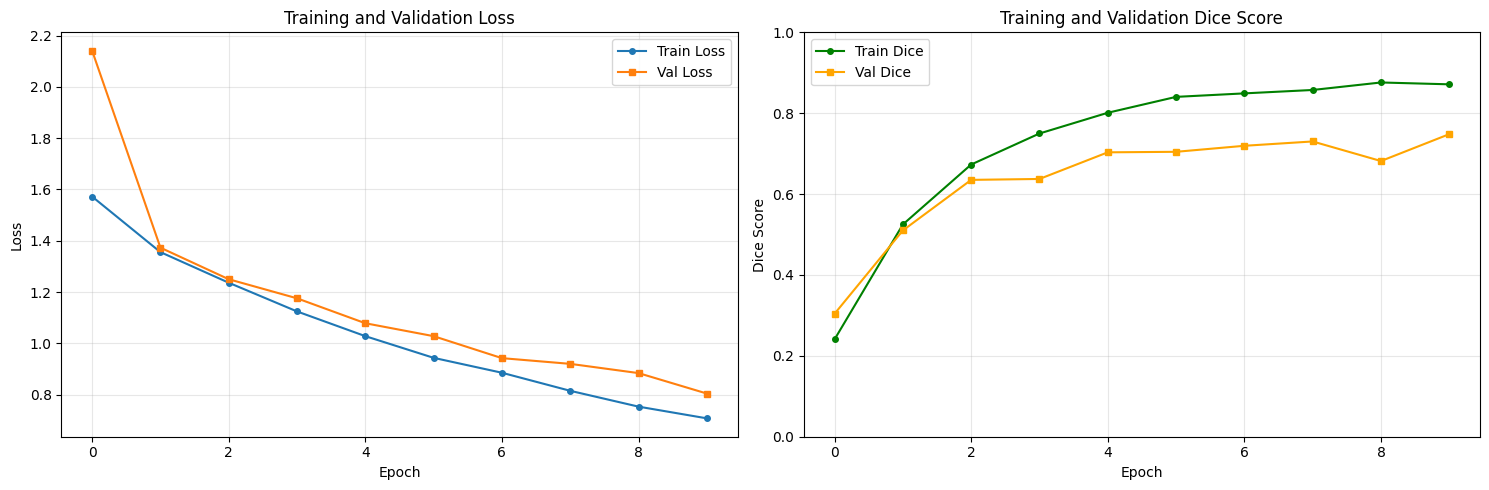

Mejor Dice Score en validación: 0.7482 (Época 10)
=== CHECKPOINT P7.1 ✔ (curvas de loss y dice) ===


In [8]:
# ============================================================
# TAREA 7.3: ENTRENAMIENTO  ✔ SOLUCIÓN
# ============================================================
from pathlib import Path
from tqdm.auto import tqdm

NUM_EPOCHS = 10  # Empezamos con pocas épocas para ver resultados rápido

# Carpeta de checkpoints en Google Drive (persiste entre sesiones/días distintos)
CHECKPOINT_DIR = Path(DRIVE_FOLDER) / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_CHECKPOINT_PATH = CHECKPOINT_DIR / 'baseline_checkpoint.pth'

train_losses = []
val_losses = []
train_dices = []
val_dices = []

def dice_score(pred_bin, target, smooth=1e-6):
    p = pred_bin.contiguous().view(-1)
    t = target.contiguous().view(-1)
    inter = (p * t).sum()
    return (2. * inter + smooth) / (p.sum() + t.sum() + smooth)

# ---------- ¿Cargar checkpoint de Drive o entrenar desde cero? ----------
# FORZAR_REENTRENAMIENTO (celda de configuración):
#   True  -> SIEMPRE entrena desde cero (modo observación: ver todo el proceso).
#   False -> Reutiliza los checkpoints guardados en Drive entre sesiones (alumno).
_cargar_checkpoint = False
if DRIVE_CHECKPOINT_PATH.exists() and not FORZAR_REENTRENAMIENTO:
    _ckpt_old = torch.load(DRIVE_CHECKPOINT_PATH, map_location=DEVICE)
    if 'train_losses' not in _ckpt_old:
        print(f"Checkpoint en formato antiguo detectado -> se borra {DRIVE_CHECKPOINT_PATH} para reentrenar.")
        DRIVE_CHECKPOINT_PATH.unlink()
    else:
        _cargar_checkpoint = True
    del _ckpt_old

if FORZAR_REENTRENAMIENTO:
    print("Modo observación: reentrenando desde cero (se ignoran los checkpoints de Drive).")

if _cargar_checkpoint:
    # Ya se entrenó este modelo en una sesión anterior: cargarlo en vez de reentrenar
    print(f"Checkpoint encontrado en Google Drive: {DRIVE_CHECKPOINT_PATH}")
    print("Cargando el mejor modelo de una sesión anterior (no hace falta reentrenar)...")
    checkpoint = torch.load(DRIVE_CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Historial: compatible con el formato nuevo (train_losses...) y con el antiguo (history)
    if 'train_losses' in checkpoint:
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
        train_dices = checkpoint['train_dices']
        val_dices = checkpoint['val_dices']
    elif isinstance(checkpoint.get('history'), dict):
        h = checkpoint['history']
        train_losses = h.get('train_losses', h.get('train_loss', []))
        val_losses = h.get('val_losses', h.get('val_loss', []))
        train_dices = h.get('train_dices', h.get('train_dice', []))
        val_dices = h.get('val_dices', h.get('val_dice', []))
    else:
        train_losses, val_losses, train_dices, val_dices = [], [], [], []
    best_val_dice = checkpoint.get('best_val_dice', -1)
    print(f"Modelo cargado. Mejor Val Dice: {best_val_dice:.4f}")

else:
    best_val_dice = -1
    BEST_MODEL_PATH = 'best_model_baseline.pth'  # checkpoint local, solo para esta sesión

    print("Iniciando entrenamiento...")
    for epoch in range(NUM_EPOCHS):
        # Fase de Entrenamiento
        model.train()
        epoch_train_loss = 0.0
        epoch_train_dice = 0.0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False):
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            with torch.no_grad():
                epoch_train_dice += dice_score((torch.sigmoid(logits) > 0.5).float(), masks).item()

        epoch_train_loss /= len(train_loader)
        epoch_train_dice /= len(train_loader)

        # Fase de Validación
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_dice = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model(images)
                loss = criterion(logits, masks)
                epoch_val_loss += loss.item()
                epoch_val_dice += dice_score((torch.sigmoid(logits) > 0.5).float(), masks).item()

        epoch_val_loss /= len(val_loader)
        epoch_val_dice /= len(val_loader)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_dices.append(epoch_train_dice)
        val_dices.append(epoch_val_dice)

        # Guardar checkpoint local si el Val Dice de esta época es el mejor hasta ahora
        is_best = epoch_val_dice > best_val_dice
        if is_best:
            best_val_dice = epoch_val_dice
            torch.save(model.state_dict(), BEST_MODEL_PATH)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {epoch_train_loss:.4f} - "
              f"Val Loss: {epoch_val_loss:.4f} | Train Dice: {epoch_train_dice:.4f} - "
              f"Val Dice: {epoch_val_dice:.4f}{'  *MEJOR*' if is_best else ''}")

    # Cargar los pesos del mejor modelo (no los de la última época)
    model.load_state_dict(torch.load(BEST_MODEL_PATH))

    # Guardar el checkpoint final (pesos + historial) en Google Drive
    torch.save({
        'model_state_dict': model.state_dict(),
        'best_val_dice': best_val_dice,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_dices': train_dices,
        'val_dices': val_dices,
    }, DRIVE_CHECKPOINT_PATH)
    print(f"\nPesos del mejor modelo restaurados en 'model' (Val Dice: {best_val_dice:.4f})")
    print(f"Checkpoint guardado en Google Drive: {DRIVE_CHECKPOINT_PATH}")

# Graficar resultados (CHECKPOINT P7.1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss', marker='o', markersize=4)
axes[0].plot(val_losses, label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_dices, label='Train Dice', marker='o', markersize=4, color='green')
axes[1].plot(val_dices, label='Val Dice', marker='s', markersize=4, color='orange')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice Score')
axes[1].set_title('Training and Validation Dice Score'); axes[1].legend()
axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Mejor Dice Score en validación: {max(val_dices):.4f} "
      f"(Época {val_dices.index(max(val_dices)) + 1})")
print("=== CHECKPOINT P7.1 ✔ (curvas de loss y dice) ===")


## Bloque 7.4: De Entrenamiento a Submission
### Qué cambia (y qué no) al pasar a inferencia

Entrenar y predecir sobre test comparten casi todo el código, con tres diferencias clave:

| | Entrenamiento / Validación | Inferencia sobre test |
|---|---|---|
| Modo del modelo | `model.train()` en train, `model.eval()` en val | `model.eval()` siempre |
| Gradientes | Se calculan en train (`loss.backward()`) | Nunca (`torch.no_grad()`) |
| ¿Hay `masks` reales? | Sí, para calcular loss y Dice | No — el test no trae máscara |
| Salida que interesa | Un número (loss, Dice) para comparar modelos | Una máscara binaria para enviar a Kaggle |

> **Nota:** al no tener máscara real en test, no podéis calcular vuestro Dice Score localmente sobre estas imágenes. La única forma de saber cómo de bien lo hace vuestro modelo ahí es subir la submission y mirar el Leaderboard.

### El preprocesamiento debe ser idéntico al de entrenamiento

Este es el punto donde más fácil es introducir un bug silencioso. El modelo aprendió a partir de imágenes preprocesadas de una manera concreta (Bloque 7.1: resize a `IMG_SIZE`, normalización con media/std de ImageNet). Si en inferencia preprocesáis distinto — aunque sea "solo" saltaros la normalización ImageNet y quedaros en `/255.0` — el modelo recibe datos con una distribución distinta a la que vio en entrenamiento, y su rendimiento cae sin que salte ningún error.

```python
# Debe ser el MISMO preprocesamiento que en BUSIDataset (Bloque 7.1), paso a paso:
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_norm = img_resized.astype(np.float32) / 255.0
img_norm = (img_norm - mean) / std          # las mismas mean/std de ImageNet
img_tensor = torch.tensor(img_norm).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
```

> **Pregunta para pensar:** si entrenáis con normalización ImageNet pero en inferencia solo dividís por 255, ¿el modelo dará un error, o simplemente predicciones peores sin avisar? ¿Por qué es más peligroso el segundo caso?

### La máscara predicha no tiene el tamaño original

El modelo siempre trabaja a `IMG_SIZE x IMG_SIZE` (por ejemplo 256x256), pero cada imagen de test tiene su propio tamaño original. Kaggle espera la máscara en la resolución original de la imagen, así que hay que deshacer el resize antes de codificar en RLE:

```
Imagen original (H0, W0)
        │  resize a IMG_SIZE
        ▼
Modelo → máscara (IMG_SIZE, IMG_SIZE)
        │  resize de vuelta a (H0, W0)
        ▼
Máscara en tamaño original → mask_to_rle()
```

Guardad `original_h, original_w` **antes** de redimensionar la imagen de entrada — es fácil olvidarlo y quedarse solo con el tamaño ya reescalado.

### De probabilidad a máscara binaria

El modelo no devuelve directamente una máscara — devuelve **logits**, que hay que convertir en dos pasos:

| Paso | Operación | Resultado |
|------|-----------|-----------|
| 1. Logits → probabilidad | `torch.sigmoid(logits)` | Valores continuos entre 0 y 1 |
| 2. Probabilidad → máscara binaria | `(probs > threshold)` | Valores 0 o 1 |

Aquí usamos `threshold = 0.5` porque es el valor por defecto razonable, pero no hay ninguna garantía de que sea el mejor corte para este problema — en la Práctica 9 buscaréis el `best_threshold` específico para vuestro modelo.

### Reutilizar `mask_to_rle`: por qué no reescribirla

La función `mask_to_rle` ya la implementasteis en la Práctica 6. La idea de un `Dataset`/pipeline bien organizado es precisamente esta: cada pieza (carga de datos, modelo, codificación RLE) se escribe una vez y se reutiliza en todas las prácticas siguientes. Si tenéis que copiar y pegar la misma lógica de RLE en cada práctica, es una señal de que conviene guardarla en una celda de utilidades al principio del notebook en vez de repetirla.

### El formato de `submission.csv`

Kaggle valida la submission comparando columnas exactas contra `sample_submission.csv`:

| Columna | Contenido |
|---------|-----------|
| `Id` | Nombre del fichero de imagen (debe coincidir exactamente con el de test) |
| `Expected` | El string RLE de la máscara predicha para esa imagen |

Una fila con un `Id` mal escrito, o un RLE con índices que no encajan con las dimensiones declaradas, hace que Kaggle rechace o puntúe mal esa fila — merece la pena comparar vuestro `submission.csv` contra `sample_submission.csv` (mismo número de filas, mismos `Id`) antes de subirlo.

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Test set | No tiene máscaras; solo sabréis vuestro Dice real al subir a Kaggle |
| Preprocesamiento | Debe ser idéntico al de entrenamiento (resize + normalización), o el modelo rinde peor sin dar error |
| Redimensionar la máscara | El modelo predice a `IMG_SIZE`; hay que devolver la máscara al tamaño original antes del RLE |
| Logits → máscara | `sigmoid()` da probabilidades, un `threshold` las convierte en máscara binaria |
| `mask_to_rle` | Reutilizar la de la Práctica 6, no reescribirla |
| `submission.csv` | Columnas `Id` y `Expected`; comparar contra `sample_submission.csv` antes de subir |




## Tarea 7.4: Inferencia y Submission a Kaggle
¡El modelo está entrenado! Ahora hay que predecir sobre las imágenes de test.
1. Itera sobre las imágenes de la carpeta `test/images`.
2. Pasa la imagen por el modelo (recuerda preprocesarla igual que en train).
3. Aplica `torch.sigmoid()` a la salida y umbraliza (ej. > 0.5) para obtener la máscara binaria.
4. Redimensiona la máscara al tamaño original de la imagen.
5. Convierte la máscara a formato RLE usando la función `mask_to_rle` de la Práctica 6.
6. Guarda los resultados en un DataFrame y expórtalo como `submission.csv`.

> **CHECKPOINT P7.2:** Descarga el `submission.csv` y súbelo a Kaggle. ¡Muestra tu posición en el Leaderboard!

In [9]:
# ============================================================
# TAREA 7.4: INFERENCIA Y SUBMISSION  ✔ SOLUCIÓN
# ============================================================
import os
import pandas as pd

# Helper: localizar imágenes de test (compatible con cualquier estructura del ZIP)
def find_test_images():
    for base in [DATA_DIR, DATA_DIR.parent, Path('/content')]:
        p = base / 'test' / 'images'
        if p.exists():
            imgs = sorted(p.glob('*.png'))
            if imgs:
                return imgs
    raise FileNotFoundError(f"No se encontraron imágenes de test bajo {DATA_DIR}/test/images")

def align_submission(submission):
    """Adapta la submission al formato EXACTO de sample_submission.csv:
    - Detecta las columnas reales del sample (Id/ImageId, Expected/EncodedPixels, Height/Width...)
    - Si el sample pide dimensiones (Height/Width), las toma de la submission
    - Deja las filas en el mismo orden de Ids que el sample.
    Limpia posibles BOM/CRLF de las cabeceras."""
    sample_path = DATA_DIR / 'sample_submission.csv'
    if not sample_path.exists():
        cands = list(DATA_DIR.rglob('sample_submission.csv'))
        sample_path = cands[0] if cands else None
    if sample_path is None:
        return submission
    sample = pd.read_csv(sample_path)
    sample.columns = [str(c).strip().lstrip('\ufeff') for c in sample.columns]

    def _find(names):
        for c in sample.columns:
            if str(c).strip().lower() in names:
                return c
        return None

    id_col  = _find(['imageid', 'id', 'filename', 'imagename']) or sample.columns[0]
    rle_col = _find(['encodedpixels', 'expected', 'rle', 'mask', 'target'])
    h_col   = _find(['height', 'h'])
    w_col   = _find(['width', 'w'])
    if rle_col is None:
        rle_col = [c for c in sample.columns if c != id_col][0]

    out = pd.DataFrame(index=range(len(sample)))
    out[id_col] = submission['Id'].values
    out[rle_col] = submission['Expected'].values
    if h_col is not None and 'Height' in submission.columns:
        out[h_col] = submission['Height'].values
    if w_col is not None and 'Width' in submission.columns:
        out[w_col] = submission['Width'].values
    out = out.set_index(id_col).loc[sample[id_col]].reset_index()
    return out[sample.columns]

test_images = find_test_images()
results = []

print("Generando predicciones para el test set...")
model.eval()
with torch.no_grad():
    for img_path in test_images:
        # 1. Cargar y preprocesar imagen (idéntico al preprocesamiento de entrenamiento)
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_norm = img_resized.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_norm = (img_norm - mean) / std
        img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        # 2. Predecir (logits -> sigmoid -> threshold > 0.5)
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)
        mask_pred = (probs > 0.5).float()

        # 3. Redimensionar máscara al tamaño original (re-binarizar tras el resize)
        mask_np = mask_pred.squeeze().cpu().numpy()
        mask_resized = cv2.resize(mask_np, (original_w, original_h))
        mask_binary = (mask_resized > 0.5).astype(np.uint8)

        # 4. Convertir a RLE y guardar (incluye dimensiones originales por si el sample las pide)
        rle = mask_to_rle(mask_binary)
        results.append({'Id': img_path.name, 'Expected': rle,
                        'Height': original_h, 'Width': original_w})

# Crear DataFrame y guardar
submission_df = pd.DataFrame(results)
assert 'Id' in submission_df.columns and len(submission_df) > 0, "No se generaron predicciones"
n_tumor = int((submission_df['Expected'] != '').sum())
submission_df = align_submission(submission_df)   # adapta al formato exacto de sample_submission.csv
submission_df.to_csv('submission.csv', index=False)
print(f"submission.csv generado correctamente: {len(submission_df)} imágenes ({n_tumor} con tumor).")
print("=== CHECKPOINT P7.2 ✔ (submission.csv listo para subir a Kaggle) ===")


Generando predicciones para el test set...
submission.csv generado correctamente: 234 imágenes (223 con tumor).
=== CHECKPOINT P7.2 ✔ (submission.csv listo para subir a Kaggle) ===


# Práctica 8: Data Augmentation y Mejora del Modelo
## Sesión única (16 Nov Grupo A / 18 Nov Grupo B)

### Objetivos de la sesión:
1. Entender las técnicas de Data Augmentation específicas para imágenes médicas
2. Implementar un pipeline de augmentation con Albumentations
3. Re-entrenar el modelo con datos augmentados
4. Comparar resultados: Baseline vs Augmented

### Reglas de oro en imágenes médicas:
- **SÍ hacer**: Rotaciones pequeñas (±15° o menos), flips, elastic deformations suaves, ajuste de brillo/contraste
- **NO hacer**: Rotaciones de 90° (pierde orientación anatómica), crops agresivos (pérdida de contexto), deformaciones extremas

> **CHECKPOINT P8:** Mostrar al profesor:
> 1. Visualización de 4-6 transformaciones aplicadas a una misma imagen
> 2. Tabla comparativa: Baseline vs Augmented (Dice Score)

## Bloque 8.1: Data Augmentation en Imágenes Médicas
### De la memorización a la generalización

En el Bloque 7.3 vimos esta señal de alarma:

| Situación | Loss | Dice | Interpretación |
|-----------|------|------|-----------------|
| Divergencia train/val | Train baja, Val sube | Train sube, Val baja | Señal de sobreajuste |

Con solo 546 imágenes de entrenamiento, un modelo con millones de parámetros (ResNet34 + decoder) tiene capacidad de sobra para **memorizar** las imágenes concretas que ve, en vez de aprender patrones que **generalicen** a imágenes nuevas. El síntoma es exactamente esa divergencia: el modelo mejora en train pero deja de mejorar (o empeora) en val.

### Data Augmentation como regularización

La idea no es conseguir más pacientes ni más ecografías reales: es fabricar **variaciones artificiales** de las imágenes que ya tenéis, para que el modelo nunca vea exactamente la misma imagen dos veces.

| Sin augmentation | Con augmentation |
|---|---|
| El modelo puede memorizar los 437 pares imagen-máscara exactos | Cada época ve versiones ligeramente distintas (rotadas, más claras, con ruido...) |
| Aprende también el ruido específico de esas imágenes | Solo sobrevive lo que es realmente **invariante** (la forma del tumor, no el brillo exacto de esa ecografía) |

> **Idea clave:** Data Augmentation no añade información nueva sobre el mundo — obliga al modelo a no depender de detalles irrelevantes de cada imagen concreta.

### Dos familias de transformaciones

En el Bloque 7.1 ya distinguimos dos tipos de transformación en un `Dataset` de segmentación, y aquí es donde importa de verdad:

| Tipo | Ejemplos | ¿Se aplica a la máscara? |
|------|----------|----------------------------|
| Geométrica | Flip, rotación, shift/scale, elastic transform | Sí, exactamente igual que a la imagen |
| Fotométrica | Brillo, contraste, ruido gaussiano | No — la máscara sigue siendo binaria (0/1) |

Si rotáis la imagen y no la máscara (o al revés), el modelo entrena con pares desalineados: aprenderá a segmentar mal, con un Dice que se desploma sin ningún error de código que lo delate.

### Por qué no todas las transformaciones valen en imagen médica

Una rotación de 90° o un flip vertical son transformaciones perfectamente válidas para fotos de gatos, pero no aquí:

| Transformación | Problema clínico |
|-----------------|-------------------|
| Rotación de 90°/180° | En ecografía mamaria la orientación de la sonda es clínicamente relevante; rotar así crea imágenes que no corresponden a ninguna adquisición real |
| Crops agresivos | Pueden eliminar el tumor por completo de la imagen sin eliminarlo de la máscara |
| Deformaciones elásticas extremas | Un tumor deformado más allá de lo fisiológicamente posible enseña al modelo formas que no existen en la realidad |

La regla general: **una transformación solo es válida si el resultado podría haber sido una adquisición real** en la consulta. Por eso las rotaciones se limitan a ±10-15° (variación plausible en el ángulo de la sonda) y no a giros completos.

### Cómo se compone un pipeline en Albumentations

```python
train_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
```

Dos detalles que suelen pasar desapercibidos:

- Cada `p=` es una probabilidad **independiente** por transformación: `p=0.5` no significa "la mitad de las imágenes se transforman", significa que *esa* transformación concreta se aplica con un 50% de probabilidad, combinándose con las demás.
- `A.Normalize` + `ToTensorV2` hacen automáticamente lo que en el Bloque 8.1 escribisteis a mano (normalización ImageNet + conversión a tensor `(C,H,W)`). Por eso a partir de aquí ya no repetiréis ese código manualmente.

### Aumentar solo el train, nunca val ni test

`train_augment` se aplica exclusivamente al `DataLoader` de entrenamiento. El de validación sigue usando el preprocesamiento simple del Bloque 8.1.

> **Pregunta para pensar:** si aplicarais también augmentation al conjunto de validación, ¿seguiría siendo una medida fiable de cómo generaliza el modelo a datos nuevos, o os estaríais engañando a vosotros mismos?

La razón es simple: val y test deben reflejar la distribución real que el modelo verá en producción (una ecografía tal cual la toma el equipo, no una versión rotada y con ruido añadido). Si medís sobre datos artificialmente aumentados, la métrica deja de ser comparable con el Leaderboard de Kaggle.

> **Pregunta para pensar:** entrenar con augmentation añade variabilidad extra en cada época — ¿esperaríais que el modelo converja igual de rápido que el baseline de la Práctica 7, con el mismo número de épocas, o necesitaría más tiempo para notarse la mejora?

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Overfitting | Train mejora, val se estanca o empeora — señal de memorización |
| Data Augmentation | Regularización: variaciones artificiales que evitan memorizar detalles irrelevantes |
| Transf. geométrica | Se aplica igual a imagen y máscara |
| Transf. fotométrica | Se aplica solo a la imagen |
| Reglas médicas | Solo transformaciones que podrían corresponder a una adquisición real |
| `p=` en Albumentations | Probabilidad independiente por transformación, no fracción del dataset |
| Alcance | Augmentation solo en train; val/test se quedan con el preprocesamiento simple |

### Referencias

1. **Shorten, C., & Khoshgoftaar, T. M. (2019).** *A survey on Image Data Augmentation for Deep Learning.* Journal of Big Data.
2. **Buslaev, A., et al. (2020).** *Albumentations: Fast and Flexible Image Augmentations.* Information.

## Tarea 8.1: ¿Por qué Data Augmentation?
### El problema del sobreajuste (Overfitting)
Cuando entrenamos con pocos datos (546 imágenes), el modelo tiende a **memorizar** en lugar de **generalizar**. Esto se manifiesta como:
- Train Loss baja mucho
- Val Loss se estanca o sube
- Train Dice alto, Val Dice bajo

### La solución: Data Augmentation
Consiste en crear **variaciones artificiales** de las imágenes de entrenamiento para:
1. Aumentar el tamaño efectivo del dataset
2. Forzar al modelo a aprender características invariantes
3. Reducir el sobreajuste

### Transformaciones específicas para ultrasonido mamario:

| Transformación | Parámetro recomendado | Justificación clínica |
|----------------|----------------------|----------------------|
| **Horizontal Flip** | p=0.5 | El seno izquierdo/derecho es simétrico |
| **Vertical Flip** | p=0.3 | Menos común pero válido |
| **Rotación** | ±15° | La sonda puede tener ángulos variados |
| **Elastic Transform** | alpha=1, sigma=50 | Simula deformaciones del tejido |
| **Gaussian Noise** | var_limit=(10,50) | Simula ruido del equipo |
| **Brightness/Contrast** | ±0.2 | Variaciones en la ganancia del equipo |

>  **IMPORTANTE**: Las máscaras deben transformarse **igual** que las imágenes para mantener la alineación.

In [10]:
# ============================================================
# TAREA 8.1: PIPELINE DE DATA AUGMENTATION  ✔ SOLUCIÓN
# ============================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Pipeline clínicamente válido: solo transformaciones que podrían corresponder a una
# adquisición real. El Resize ya lo hace BUSIDataset; se evitan rotaciones de 90°
# (cambiarían la orientación anatómica de la sonda).
train_augment = A.Compose([
    A.HorizontalFlip(p=0.5),                       # simetría del seno
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=10,
                       p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),       # ruido del equipo
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=0, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("Pipeline de augmentation definido")


Pipeline de augmentation definido


/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_354/2987981406.py:16: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),       # ruido del equipo
/tmp/ipykernel_354/2987981406.py:17: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=0, p=0.3),


## Bloque 8.2: Verificar Visualmente un Pipeline de Augmentation
### Por qué visualizar antes de entrenar

Un pipeline de Albumentations mal configurado no lanza ningún error — simplemente entrena con datos deformados de forma silenciosa. Descubrir esto después de 30 épocas de entrenamiento (varios minutos u horas de GPU) es mucho más caro que descubrirlo mirando una figura con 6 ejemplos antes de empezar. Por eso, en cualquier pipeline de augmentation nuevo, la primera comprobación siempre es visual, no numérica.

### Cada llamada al pipeline es aleatoria

`train_augment` no es una función determinista: cada vez que la llamáis sobre la misma imagen, el resultado es distinto. Esto ocurre porque, en cada llamada, el pipeline:

1. Decide para cada transformación si se aplica o no, según su `p=` (una tirada de moneda independiente por transformación).
2. Si se aplica, muestrea sus parámetros al azar dentro del rango configurado (por ejemplo, `A.Rotate(limit=10)` elige un ángulo aleatorio entre -10° y +10°, no siempre el mismo).

| Llamada | HorizontalFlip (p=0.5) | Rotate (limit=10) |
|---------|--------------------------|---------------------|
| 1 | No se aplica | +7° |
| 2 | Se aplica | -3° |
| 3 | Se aplica | +10° |

Por eso, al llamar a `train_augment` 6 veces sobre la misma imagen de entrada, obtenéis 6 salidas distintas — es el comportamiento esperado, no un bug. Durante el entrenamiento real esto es justo lo que queréis: cada época, cada imagen se transforma de forma distinta.

### El pipeline termina en tensor normalizado: hay que deshacerlo para poder verlo

Si recordáis el Bloque 8.1, `train_augment` termina con `A.Normalize(...)` y `ToTensorV2()`. Eso significa que lo que devuelve **no es una imagen visualizable directamente**:

| Propiedad | Imagen "normal" (para `plt.imshow`) | Salida de `train_augment` |
|-----------|----------------------------------------|------------------------------|
| Forma | `(H, W, C)` | `(C, H, W)` |
| Rango de valores | `[0, 1]` o `[0, 255]` | Centrado en 0, puede ser negativo |
| Tipo | `numpy.ndarray` | `torch.Tensor` |

Para poder visualizarla hay que deshacer exactamente esos tres pasos, en orden inverso:

```python
aug_img = augmented['image'].permute(1, 2, 0).numpy()          # (C,H,W) -> (H,W,C)
aug_img = aug_img * std + mean                                  # deshacer la normalización ImageNet
aug_img = np.clip(aug_img, 0, 1)                                 # errores de redondeo pueden salirse de [0,1]
```

> **Nota:** el `np.clip` no es cosmético — sin él, `matplotlib` puede mostrar colores extraños o lanzar un aviso, porque tras la operación `* std + mean` algunos píxeles pueden quedar ligeramente fuera de `[0, 1]` por precisión numérica.

### Qué mirar en las imágenes generadas

No basta con comprobar que "se ve algo distinto" en cada versión. Revisad específicamente:

- ¿Sigue siendo reconocible la anatomía, o la transformación es tan agresiva que ya no parece una ecografía real?
- ¿Han aparecido bordes negros o artefactos por el relleno (`border_mode`) que usa la rotación o el shift al salirse del marco original?
- ¿Alguna combinación de transformaciones (rotación + brillo + ruido a la vez) produce una imagen irreconocible, aunque cada transformación individual pareciera razonable?

> **Pregunta para pensar:** si al ver las 6 imágenes augmentadas 2 de ellas os parecen clínicamente irreconocibles (no se distingue tejido de fondo), ¿qué parte del pipeline del Bloque 8.1 revisaríais primero?

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Visualizar antes de entrenar | Detecta pipelines rotos sin gastar horas de entrenamiento |
| Aleatoriedad | Cada llamada resuelve de nuevo el `p=` y remuestrea parámetros; 6 llamadas → 6 resultados distintos |
| Desnormalizar | `permute` para volver a `(H,W,C)`, deshacer `Normalize` con `*std + mean`, y `clip` a `[0,1]` |
| Qué revisar | Anatomía reconocible, artefactos de borde, combinaciones demasiado agresivas |

## Tarea 8.2: Visualización de las Transformaciones
Antes de re-entrenar, vamos a visualizar cómo se ven las imágenes con las transformaciones aplicadas.

### Instrucciones:
1. Carga una imagen de ejemplo del dataset de train
2. Aplica el pipeline `train_augment` 6 veces a la misma imagen
3. Muestra la imagen original + 6 versiones augmentadas en una figura de 1x7
4. Observa cómo cambian: rotación, brillo, deformación, etc.

> **CHECKPOINT P8.1:** Muestra al profesor la figura con las 7 imágenes (original + 6 augmentadas)

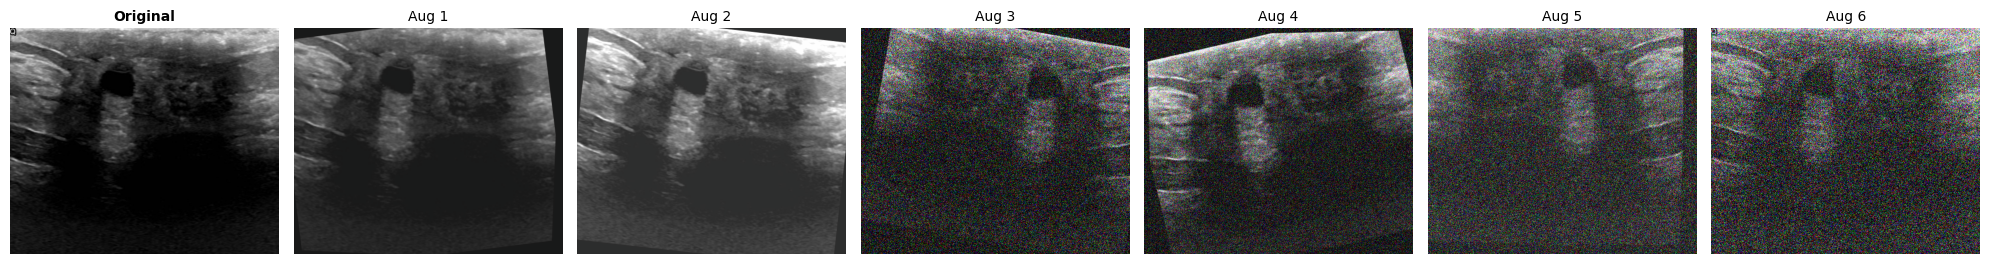

=== CHECKPOINT P8.1 ✔ (original + 6 versiones augmentadas) ===


In [11]:
# ============================================================
# TAREA 8.2: VISUALIZACIÓN DE AUGMENTATIONS  ✔ SOLUCIÓN
# ============================================================
sample_img = cv2.cvtColor(cv2.imread(df_train.iloc[0]['image_path']), cv2.COLOR_BGR2RGB)
dummy_mask = np.zeros(sample_img.shape[:2], dtype=np.uint8)

fig, axes = plt.subplots(1, 7, figsize=(20, 4))
axes[0].imshow(sample_img); axes[0].set_title("Original", fontsize=10, fontweight='bold'); axes[0].axis('off')

mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
for i in range(1, 7):
    aug = train_augment(image=sample_img, mask=dummy_mask)
    img = aug['image'].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)   # desnormalizar para visualizar
    axes[i].imshow(img); axes[i].set_title(f"Aug {i}", fontsize=10); axes[i].axis('off')

plt.tight_layout()
plt.show()
print("=== CHECKPOINT P8.1 ✔ (original + 6 versiones augmentadas) ===")


## Bloque 8.3: Repetir un Experimento de Forma Justa
### Por qué reinicializar el modelo en vez de continuar entrenando

`model_aug = smp.Unet(...)` crea un modelo **nuevo desde cero**, no continúa entrenando el `model` de la Práctica 7. Esto no es un descuido: si continuarais entrenando el modelo baseline ya convergido, cualquier mejora en el Dice no podríais atribuirla al augmentation — podría deberse simplemente a que el modelo llevaba más épocas entrenando en total.

> **Idea clave:** para que la comparación Baseline vs Augmented signifique algo, ambos modelos deben partir de la misma situación de salida (arquitectura recién inicializada) y diferir en **una sola cosa**: los datos que ven durante el entrenamiento.

### Variable de control: cambiar una cosa, no dos

Esto es el mismo principio que un experimento controlado en cualquier ciencia experimental:

| Elemento | Baseline (P7) | Augmented (P8) | ¿Cambia? |
|----------|----------------|-------------------|-----------|
| Arquitectura (`smp.Unet(...)`) | ResNet34 + decoder | ResNet34 + decoder | No |
| `NUM_EPOCHS` | El mismo valor | El mismo valor | No |
| Optimizador y `lr` | `Adam`, `lr=1e-4` | `Adam`, `lr=1e-4` | No |
| Función de pérdida | `DiceBCELoss` | `DiceBCELoss` | No |
| Datos de entrenamiento | Sin augmentation | Con `train_augment` | **Sí — la única variable** |

Si cambiarais también el número de épocas o el learning rate al mismo tiempo que añadís augmentation, y el Dice mejora, no sabríais si mejoró por el augmentation o por el otro cambio. Un experimento con dos variables a la vez no permite sacar conclusiones de ninguna de las dos.

### El riesgo real de "reutilizar el código de P7"

La instrucción de la tarea dice literalmente "copia el código de entrenamiento de P7 y modifica solo el DataLoader". Ese copia-pega es exactamente donde se cuela el bug más común de esta práctica: si olvidáis renombrar alguna variable, sobrescribís sin querer los resultados del baseline.

| Variable original (P7) | Variable nueva (P8) | Si os olvidáis de renombrar... |
|---|---|---|
| `model` | `model_aug` | Seguís entrenando/evaluando el modelo baseline, no uno nuevo |
| `optimizer` | `optimizer_aug` | El optimizador sigue ligado a los parámetros del modelo baseline |
| `train_loader` | `train_loader_aug` | Entrenáis otra vez sin augmentation, aunque creáis que sí lo tiene |
| `train_losses`, `val_losses`, `train_dices`, `val_dices` | `..._aug` | **Sobrescribís las listas del baseline** — en la Tarea 8.4 ya no podréis comparar nada, porque baseline y augmented serán la misma lista |

> **Pregunta para pensar:** si en la Tarea 8.4 vuestra gráfica "Baseline vs Augmented" muestra dos líneas idénticas, ¿cuál de las variables de la tabla anterior sospecharíais primero que no se renombró?

### Una sola ejecución no es una prueba definitiva

En el Bloque 7.3 vimos que Loss y Dice pueden divergir (la "meseta engañosa"). Lo mismo aplica aquí: entrenar una vez cada configuración os da un dato, no una certeza estadística. Diferencias pequeñas en el Dice final entre baseline y augmented pueden deberse en parte a variabilidad normal del entrenamiento (inicialización aleatoria de pesos, orden de batches), no solo al augmentation en sí. Esto no invalida el experimento — solo hay que tenerlo en cuenta al interpretar una diferencia pequeña como "augmentation ganó" o "augmentation perdió".

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Reinicializar el modelo | Evita que la mejora se deba a "más épocas totales" en vez de al augmentation |
| Variable de control | Todo igual entre baseline y augmented excepto los datos de entrenamiento |
| Riesgo de copiar código | Olvidar renombrar variables sobrescribe silenciosamente los resultados del baseline |
| Una sola ejecución | Las diferencias pequeñas pueden ser variabilidad normal, no solo efecto del augmentation |

## Tarea 8.3: Re-entrenamiento con Augmentation
Ahora vamos a re-entrenar el modelo usando el nuevo DataLoader con augmentation.

### Instrucciones:
1. Crea un nuevo `BUSIDataset` (que permita transformaciones) usando `train_augment` en lugar del transform base
2. Crea un nuevo `DataLoader` para train (el de val puede quedarse igual)
3. Re-inicializa el modelo U-Net (para empezar desde cero)
4. Entrena durante `NUM_EPOCHS` épocas (usa el mismo código de entrenamiento de P7)
5. Guarda las métricas: `train_losses_aug`, `val_losses_aug`, `train_dices_aug`, `val_dices_aug`
6. Aplica el mismo patrón de checkpointing que en la P7, pero con `model_aug`: guarda los pesos localmente cada vez que mejore el Val Dice, y al terminar el bucle guarda también el checkpoint final (pesos + historial) en Google Drive — mismo `CHECKPOINT_DIR` de la P7, pero con un fichero distinto (por ejemplo `augmented_checkpoint.pth`) para no sobrescribir el del baseline. Comprueba primero si ese checkpoint ya existe en Drive: si es así, cárgalo y no reentrenes.
6. Aplica el mismo checkpointing que en la P7 (guardar el mejor modelo según Val Dice y recargarlo al final), pero usando `model_aug` y un fichero distinto (por ejemplo `best_model_augmented.pth`) para no sobrescribir el checkpoint del baseline.

> **Pista**: Puedes copiar el código de entrenamiento de P7 y modificar solo el DataLoader

In [12]:
# ============================================================
# TAREA 8.3: RE-ENTRENAMIENTO CON AUGMENTATION  ✔ SOLUCIÓN
# ============================================================
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

DRIVE_CHECKPOINT_PATH_AUG = CHECKPOINT_DIR / 'augmented_checkpoint.pth'

# 1. Crear nuevo Dataset con augmentation (BUSIDataset ya soporta transform)
train_dataset_aug = BUSIDataset(train_df, transform=train_augment)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# 2. Re-inicializar modelo (para empezar desde cero: experimento justo)
model_aug = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
                     in_channels=3, classes=1, activation=None)
model_aug = model_aug.to(DEVICE)

# 3. Optimizador
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-4)

# 4. Entrenar
train_losses_aug = []
val_losses_aug = []
train_dices_aug = []
val_dices_aug = []

# ---------- ¿Cargar checkpoint de Drive o entrenar desde cero? ----------
# FORZAR_REENTRENAMIENTO (celda de configuración):
#   True  -> SIEMPRE entrena desde cero (modo observación: ver todo el proceso).
#   False -> Reutiliza los checkpoints guardados en Drive entre sesiones (alumno).
_cargar_checkpoint_aug = False
if DRIVE_CHECKPOINT_PATH_AUG.exists() and not FORZAR_REENTRENAMIENTO:
    _ckpt_old = torch.load(DRIVE_CHECKPOINT_PATH_AUG, map_location=DEVICE)
    if 'train_losses' not in _ckpt_old:
        print(f"Checkpoint en formato antiguo detectado -> se borra {DRIVE_CHECKPOINT_PATH_AUG} para reentrenar.")
        DRIVE_CHECKPOINT_PATH_AUG.unlink()
    else:
        _cargar_checkpoint_aug = True
    del _ckpt_old

if FORZAR_REENTRENAMIENTO:
    print("Modo observación: reentrenando desde cero (se ignoran los checkpoints de Drive).")

if _cargar_checkpoint_aug:
    print(f"Checkpoint encontrado en Google Drive: {DRIVE_CHECKPOINT_PATH_AUG}")
    print("Cargando el mejor modelo augmented de una sesión anterior (no hace falta reentrenar)...")
    checkpoint = torch.load(DRIVE_CHECKPOINT_PATH_AUG, map_location=DEVICE)
    model_aug.load_state_dict(checkpoint['model_state_dict'])

    # Historial: compatible con el formato nuevo (train_losses...) y con el antiguo (history)
    if 'train_losses' in checkpoint:
        train_losses_aug = checkpoint['train_losses']
        val_losses_aug = checkpoint['val_losses']
        train_dices_aug = checkpoint['train_dices']
        val_dices_aug = checkpoint['val_dices']
    elif isinstance(checkpoint.get('history'), dict):
        h = checkpoint['history']
        train_losses_aug = h.get('train_losses', h.get('train_loss', []))
        val_losses_aug = h.get('val_losses', h.get('val_loss', []))
        train_dices_aug = h.get('train_dices', h.get('train_dice', []))
        val_dices_aug = h.get('val_dices', h.get('val_dice', []))
    else:
        train_losses_aug, val_losses_aug, train_dices_aug, val_dices_aug = [], [], [], []
    best_val_dice_aug = checkpoint.get('best_val_dice', -1)
    print(f"Modelo cargado. Mejor Val Dice: {best_val_dice_aug:.4f}")

else:
    best_val_dice_aug = -1
    BEST_MODEL_PATH_AUG = 'best_model_augmented.pth'

    print("Entrenando con augmentation...")
    for epoch in range(NUM_EPOCHS):
        # Fase de Entrenamiento
        model_aug.train()
        epoch_train_loss = 0.0
        epoch_train_dice = 0.0

        for images, masks in tqdm(train_loader_aug, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False):
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer_aug.zero_grad()
            logits = model_aug(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer_aug.step()

            epoch_train_loss += loss.item()
            with torch.no_grad():
                epoch_train_dice += dice_score((torch.sigmoid(logits) > 0.5).float(), masks).item()

        epoch_train_loss /= len(train_loader_aug)
        epoch_train_dice /= len(train_loader_aug)

        # Fase de Validación
        model_aug.eval()
        epoch_val_loss = 0.0
        epoch_val_dice = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model_aug(images)
                loss = criterion(logits, masks)
                epoch_val_loss += loss.item()
                epoch_val_dice += dice_score((torch.sigmoid(logits) > 0.5).float(), masks).item()

        epoch_val_loss /= len(val_loader)
        epoch_val_dice /= len(val_loader)

        train_losses_aug.append(epoch_train_loss)
        val_losses_aug.append(epoch_val_loss)
        train_dices_aug.append(epoch_train_dice)
        val_dices_aug.append(epoch_val_dice)

        is_best = epoch_val_dice > best_val_dice_aug
        if is_best:
            best_val_dice_aug = epoch_val_dice
            torch.save(model_aug.state_dict(), BEST_MODEL_PATH_AUG)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {epoch_train_loss:.4f} - "
              f"Val Loss: {epoch_val_loss:.4f} | Train Dice: {epoch_train_dice:.4f} - "
              f"Val Dice: {epoch_val_dice:.4f}{'  *MEJOR*' if is_best else ''}")

    model_aug.load_state_dict(torch.load(BEST_MODEL_PATH_AUG))
    torch.save({
        'model_state_dict': model_aug.state_dict(),
        'best_val_dice': best_val_dice_aug,
        'train_losses': train_losses_aug,
        'val_losses': val_losses_aug,
        'train_dices': train_dices_aug,
        'val_dices': val_dices_aug,
    }, DRIVE_CHECKPOINT_PATH_AUG)
    print(f"\nPesos del mejor modelo restaurados en 'model_aug' (Val Dice: {best_val_dice_aug:.4f})")
    print(f"Checkpoint guardado en Google Drive: {DRIVE_CHECKPOINT_PATH_AUG}")

print(f"Mejor Dice Score en validación (augmented): {max(val_dices_aug):.4f} "
      f"(Época {val_dices_aug.index(max(val_dices_aug)) + 1})")


Modo observación: reentrenando desde cero (se ignoran los checkpoints de Drive).
Entrenando con augmentation...


Epoch 1/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 1.4630 - Val Loss: 1.4584 | Train Dice: 0.2403 - Val Dice: 0.2921  *MEJOR*


Epoch 2/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 2/10 - Train Loss: 1.2126 - Val Loss: 1.1479 | Train Dice: 0.4621 - Val Dice: 0.5760  *MEJOR*


...

Epoch 8/10 - Train Loss: 0.6624 - Val Loss: 0.6745 | Train Dice: 0.7536 - Val Dice: 0.7122  *MEJOR*


Epoch 9/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.5991 - Val Loss: 0.6582 | Train Dice: 0.7773 - Val Dice: 0.7208  *MEJOR*


Epoch 10/10 [Train]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.5747 - Val Loss: 0.6405 | Train Dice: 0.7765 - Val Dice: 0.7054

Pesos del mejor modelo restaurados en 'model_aug' (Val Dice: 0.7208)
Checkpoint guardado en Google Drive: /content/drive/MyDrive/PIM_Challenge/checkpoints/augmented_checkpoint.pth
Mejor Dice Score en validación (augmented): 0.7208 (Época 9)


## Bloque 8.4: Leer una Comparativa de Curvas de Entrenamiento
### Cuatro paneles, cuatro preguntas distintas

La figura 2x2 no es simplemente "cuatro gráficas bonitas" — cada panel responde a una pregunta diferente, y hay que leerlos en ese orden:

| Panel | Pregunta que responde |
|-------|--------------------------|
| Train Loss | ¿Sigue aprendiendo el modelo sobre los datos que ve? |
| Train Dice | ¿Qué tan bien ajusta cada modelo los datos de entrenamiento? |
| Val Loss | ¿Cuál generaliza mejor según la función de pérdida? |
| Val Dice | ¿Cuál generaliza mejor según la métrica que realmente importa? |

### La métrica que de verdad decide: Val Dice

De los cuatro paneles, **Val Dice** es el que más se parece a lo que Kaggle va a puntuar sobre el test set (que no habéis visto). Train Loss y Train Dice solo os dicen qué tan bien memoriza cada modelo los datos que ya conoce — un valor alto ahí no garantiza nada sobre imágenes nuevas.

> **Idea clave:** si tuvierais que quedaros con un solo número para decidir qué modelo subir a Kaggle, sería el mejor Val Dice, no el mejor Train Dice.

### No miréis solo el valor final: mirad la brecha train-val

Recordad el Bloque 8.1: el síntoma de sobreajuste es que train y val se separan. Por eso la comparación más informativa no es "¿qué Val Dice final tiene cada modelo?", sino "¿qué distancia hay entre Train Dice y Val Dice en cada uno?":

| Modelo | Train Dice alto y Val Dice bajo (brecha grande) | Train Dice y Val Dice parecidos (brecha pequeña) |
|--------|----------------------------------------------------|-------------------------------------------------------|
| Interpretación | Sobreajuste: memoriza train, no generaliza | Generaliza mejor, aunque su Dice absoluto sea algo menor |

Es perfectamente posible que el modelo Augmented tenga un Train Dice **más bajo** que el Baseline (porque entrena con datos más difíciles y variados) y aun así sea el modelo que mejor generaliza, si su brecha train-val es menor.

### Ejes comparables: por qué fijar los mismos límites

Las instrucciones piden `axes[...].set_ylim(0, 1)` en los paneles de Dice. Esto no es estético: si cada subplot ajustara automáticamente su propio rango de eje Y, dos curvas con diferencias reales podrían parecer visualmente idénticas (o al revés, diferencias mínimas podrían parecer enormes) solo por el zoom automático de matplotlib. Para comparar de forma honesta, ambas curvas de un mismo panel deben compartir escala.

### Una diferencia pequeña no siempre es una victoria

Como vimos en el Bloque 8.3, una sola ejecución tiene variabilidad inherente. Si el Val Dice final del Augmented es, por ejemplo, 0.76 frente a 0.74 del Baseline, esa diferencia de 2 puntos puede deberse tanto al augmentation como al azar de esa ejecución concreta. Una diferencia consistente y visible durante varias épocas (no solo en el último punto) es una señal más fiable que comparar un único valor final.

> **Pregunta para pensar:** si al terminar veis que el Augmented tiene peor Val Dice que el Baseline con el mismo número de épocas, ¿descartaríais inmediatamente el augmentation, o hay algo en el Bloque 8.1 (sobre la dificultad añadida de entrenar con más variabilidad) que sugiera revisar antes de concluir nada?

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Cuatro paneles | Cada uno responde una pregunta distinta; no son intercambiables |
| Val Dice | La métrica más parecida a lo que evalúa Kaggle |
| Brecha train-val | Más informativa que el valor final aislado; brecha pequeña = mejor generalización |
| Ejes compartidos | `set_ylim` igual en ambas curvas evita comparaciones visualmente engañosas |
| Diferencia pequeña | Puede ser variabilidad de una sola ejecución, no una conclusión sólida |

## Tarea 8.4: Comparativa Baseline vs Augmented
Es hora de comparar los resultados. Vamos a visualizar las curvas de entrenamiento de ambos modelos lado a lado.

### Instrucciones:
1. Crea una figura de 2x2 con:
   - Gráfico 1: Train Loss (Baseline vs Augmented)
   - Gráfico 2: Val Loss (Baseline vs Augmented)
   - Gráfico 3: Train Dice (Baseline vs Augmented)
   - Gráfico 4: Val Dice (Baseline vs Augmented)
2. Usa diferentes colores para cada modelo
3. Añade leyendas, títulos y grid

> **CHECKPOINT P8.2:** Muestra al profesor la figura comparativa y explica las diferencias observadas

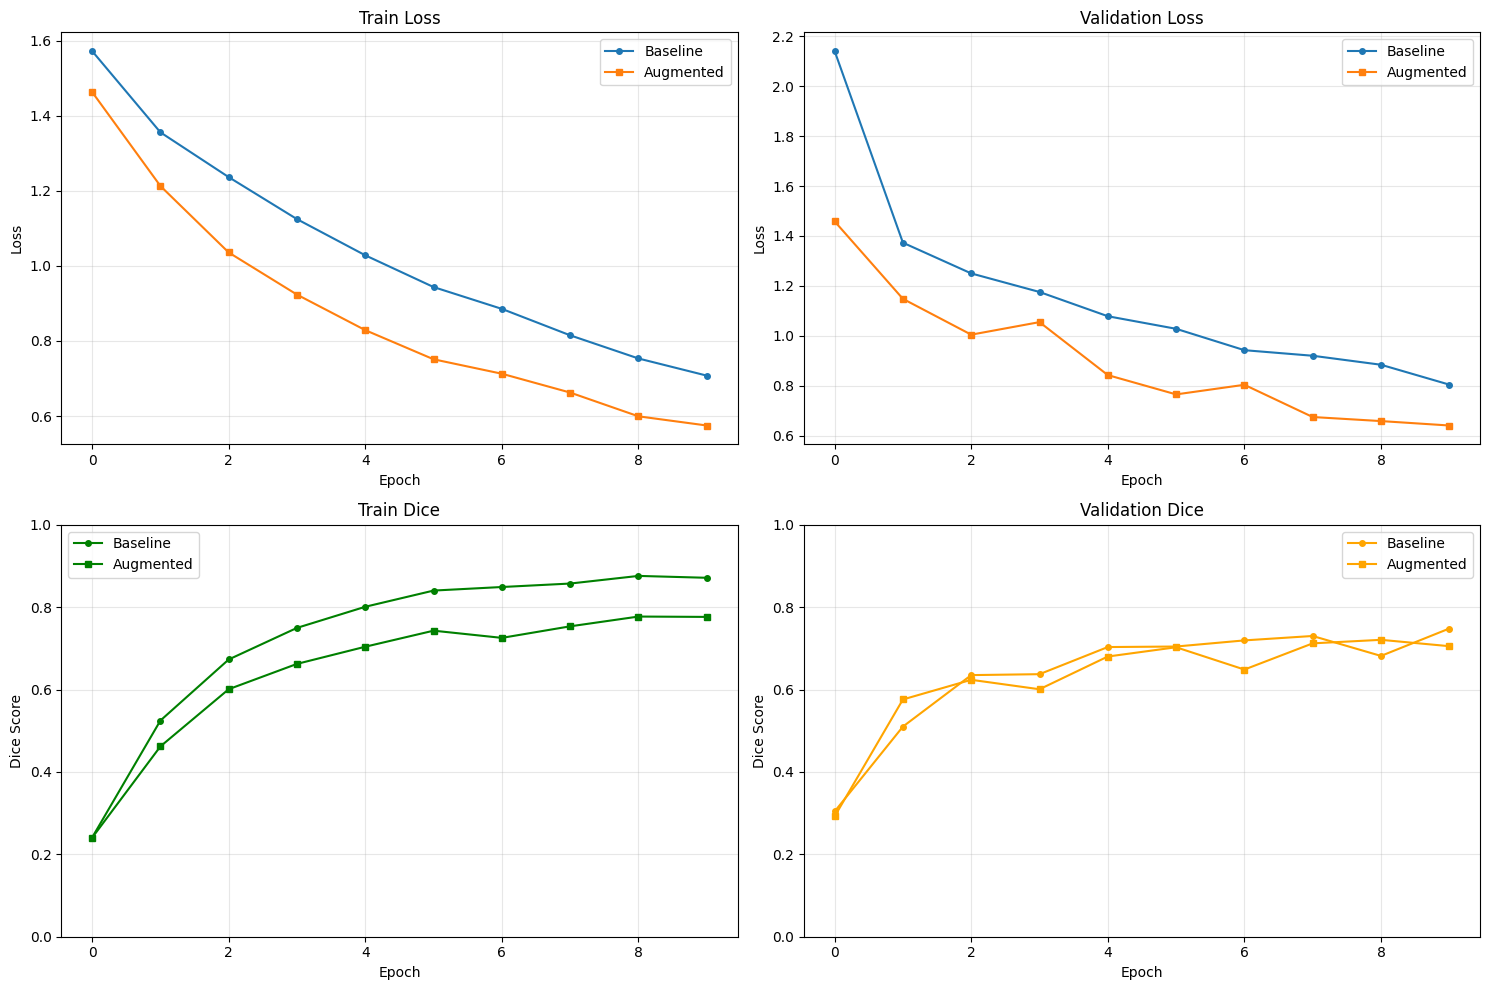


RESUMEN COMPARATIVO
Baseline  - Mejor Val Dice: 0.7482 (Época 10)
Augmented - Mejor Val Dice: 0.7208 (Época 9)
Mejora: -0.0274
La augmentation no mejoró el modelo en esta ejecución (prueba más épocas).
=== CHECKPOINT P8.2 ✔ (comparativa Baseline vs Augmented) ===


In [13]:
# ============================================================
# TAREA 8.4: COMPARATIVA BASELINE VS AUGMENTED  ✔ SOLUCIÓN
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(train_losses, label='Baseline', marker='o', markersize=4)
axes[0, 0].plot(train_losses_aug, label='Augmented', marker='s', markersize=4)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Train Loss'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(val_losses, label='Baseline', marker='o', markersize=4)
axes[0, 1].plot(val_losses_aug, label='Augmented', marker='s', markersize=4)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(train_dices, label='Baseline', marker='o', markersize=4, color='green')
axes[1, 0].plot(train_dices_aug, label='Augmented', marker='s', markersize=4, color='green')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Dice Score')
axes[1, 0].set_title('Train Dice'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(val_dices, label='Baseline', marker='o', markersize=4, color='orange')
axes[1, 1].plot(val_dices_aug, label='Augmented', marker='s', markersize=4, color='orange')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Dice Score')
axes[1, 1].set_title('Validation Dice'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESUMEN COMPARATIVO")
print("="*60)
print(f"Baseline  - Mejor Val Dice: {max(val_dices):.4f} (Época {val_dices.index(max(val_dices)) + 1})")
print(f"Augmented - Mejor Val Dice: {max(val_dices_aug):.4f} (Época {val_dices_aug.index(max(val_dices_aug)) + 1})")
print(f"Mejora: {max(val_dices_aug) - max(val_dices):+.4f}")
if max(val_dices_aug) > max(val_dices):
    print("¡La augmentation mejoró el modelo!")
else:
    print("La augmentation no mejoró el modelo en esta ejecución (prueba más épocas).")
print("=== CHECKPOINT P8.2 ✔ (comparativa Baseline vs Augmented) ===")


# Práctica 9: Inferencia, Optimización de Threshold y Análisis de Errores
## Sesión única (23 Nov Grupo A / 25 Nov Grupo B)

### Objetivos de la sesión:
1. Entender por qué el umbral de decisión (threshold) de 0.5 no siempre es el óptimo en medicina.
2. Calcular el **Threshold Óptimo** evaluando el conjunto de validación.
3. Realizar un **Análisis Cualitativo de Errores** (Falsos Positivos y Falsos Negativos).
4. Generar la **Submission Final** para Kaggle.

###  Contexto Clínico: El dilema FP vs FN
En la detección de cáncer de mama:
*   **Falso Negativo (FN):** Decir que no hay tumor cuando sí lo hay. (Grave: retraso en el tratamiento).
*   **Falso Positivo (FP):** Decir que hay tumor cuando no lo hay. (Ansiedad, biopsias innecesarias).

Nuestro modelo debe encontrar el equilibrio perfecto. Hoy vamos a buscarlo.

> **CHECKPOINT P9:** Mostrar al profesor:
> 1. Gráfica de Threshold vs Dice Score con el punto óptimo marcado.
> 2. Visualización de 5 casos críticos (incluyendo al menos 1 imagen "normal" y 1 error grave).

## Antes de empezar: elegir el modelo definitivo (P7 baseline vs P8 augmented)

En el Bloque 9.3 se habla del "modelo definitivo": el que mejor Val Dice haya conseguido entre el baseline (P7) y el augmented (P8). La celda siguiente carga **desde Drive** los checkpoints de ambos, compara su Val Dice, y deja el ganador en la variable `model` — así no hay que decidirlo a mano ni arriesgarse a usar por descuido el que no tocaba.


In [14]:
# ============================================================
# Elegir el "modelo definitivo": el mejor Val Dice entre baseline y augmented
# ============================================================
paths = {
    'baseline (P7)': CHECKPOINT_DIR / 'baseline_checkpoint.pth',
    'augmented (P8)': CHECKPOINT_DIR / 'augmented_checkpoint.pth',
}

candidates = {}
for name, path in paths.items():
    if path.exists():
        ckpt = torch.load(path, map_location=DEVICE)
        candidates[name] = ckpt
        print(f"{name}: Val Dice = {ckpt['best_val_dice']:.4f}")
    else:
        print(f"{name}: no encontrado en Drive ({path})")

if not candidates:
    raise FileNotFoundError("No se encontró ningún checkpoint. Completa antes la P7 y/o la P8.")

best_name = max(candidates, key=lambda n: candidates[n]['best_val_dice'])
best_checkpoint = candidates[best_name]

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1, activation=None)
model = model.to(DEVICE)
model.load_state_dict(best_checkpoint['model_state_dict'])

print(f"\nModelo definitivo: {best_name} (Val Dice = {best_checkpoint['best_val_dice']:.4f})")


baseline (P7): Val Dice = 0.7482
augmented (P8): Val Dice = 0.7208

Modelo definitivo: baseline (P7) (Val Dice = 0.7482)


## Bloque 9.1: El Threshold como Hiperparámetro
### 0.5 nunca fue una decisión informada

Desde la Práctica 7 habéis usado `probs > 0.5` para convertir probabilidades en máscara binaria. Ese 0.5 no salió de ningún análisis de vuestros datos: es simplemente el punto medio del rango de `sigmoid()` (que va de 0 a 1), la opción por defecto más "neutra" posible. Nada garantiza que sea el mejor corte para este dataset en concreto.

> **Idea clave:** el threshold es un hiperparámetro más de vuestro sistema, igual que `lr` o `NUM_EPOCHS` — simplemente hasta ahora lo habíais dejado fijo sin cuestionarlo.

### Por qué el threshold no es gratis: precisión vs recall

Recordad el dilema clínico de la introducción de esta práctica: un Falso Negativo (no detectar un tumor real) y un Falso Positivo (detectar un tumor que no existe) no tienen el mismo coste. El threshold controla directamente ese equilibrio:

| Threshold | Efecto en la máscara | Consecuencia |
|-----------|------------------------|----------------|
| Más bajo (ej. 0.3) | El modelo marca "tumor" con menos evidencia | Menos Falsos Negativos, más Falsos Positivos |
| Más alto (ej. 0.7) | El modelo exige más confianza para marcar "tumor" | Menos Falsos Positivos, más Falsos Negativos |

El Dice Score que vais a maximizar es una media que pondera precisión y recall por igual — no distingue si os equivocáis por FP o por FN. Maximizar Dice os da el mejor equilibrio *estadístico*, pero no necesariamente el mejor equilibrio *clínico* (donde un FN suele ser más grave que un FP).

> **Pregunta para pensar:** si fuerais los responsables clínicos de este sistema y tuvierais que elegir entre el threshold que maximiza el Dice y uno ligeramente distinto que reduce los Falsos Negativos a costa de algo de Dice, ¿cuál eligiríais? ¿Por qué el ejercicio, aun así, os pide maximizar el Dice?

### Por qué se busca en validación, no en train ni en test

Este es exactamente el mismo principio de las Prácticas 7 y 8 aplicado a un hiperparámetro nuevo:

| Conjunto | ¿Por qué NO usarlo para elegir el threshold? |
|----------|-------------------------------------------------|
| Train | El modelo ya vio estos datos al entrenar; el threshold quedaría ajustado al ruido específico de esas imágenes |
| Test | No tiene máscaras — no podéis calcular Dice ahí. Y aunque las tuvierais, elegir el threshold mirando el test sería "hacer trampa": estaríais ajustando un hiperparámetro con los mismos datos con los que luego os evalúan |
| Val | Datos que el modelo no usó para ajustar pesos, y sí tenéis máscaras para medir Dice — la elección justa |

### Por qué no hace falta reentrenar para probar cada threshold

A diferencia de cambiar `lr` o añadir augmentation (que obligan a entrenar el modelo entero otra vez), el threshold se aplica **después** de que el modelo ya generó sus probabilidades. Los pesos del modelo no cambian entre un threshold y otro — solo cambia dónde cortáis esas probabilidades para decidir 0 o 1. Por eso podéis barrer 17 valores de threshold (0.1 a 0.9 en pasos de 0.05) evaluando el `val_loader` una vez por cada uno, sin ningún coste de entrenamiento.

### Cómo interpretar la curva Threshold vs Dice

La forma típica de esta curva es una campana: Dice bajo en los extremos (thresholds muy bajos generan demasiados Falsos Positivos; muy altos, demasiados Falsos Negativos) y un máximo en algún punto intermedio.

| Forma de la curva | Interpretación |
|----------------------|-------------------|
| Pico marcado y estrecho | El threshold importa mucho; elegir mal cuesta Dice de forma notable |
| Curva plana en la zona central | El modelo es robusto al threshold exacto; varios valores cercanos dan un Dice similar |

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Threshold | Un hiperparámetro más, no una constante fija |
| Precisión vs recall | Threshold bajo → menos FN, más FP; threshold alto → lo contrario |
| Dónde buscarlo | En validación: train sesga el ajuste, test invalidaría la evaluación |
| Coste de la búsqueda | Ninguno de entrenamiento — el modelo no cambia, solo el corte de decisión |
| Forma de la curva | Un pico marcado indica que el threshold importa; una curva plana indica que el modelo es robusto en un rango de valores |

## Tarea 9.1: Búsqueda del Threshold Óptimo
Hasta ahora hemos usado `threshold = 0.5` para binarizar las probabilidades. Pero, ¿es realmente el mejor valor para nuestro dataset?

### Instrucciones:
1. Pon el modelo en modo evaluación (`model.eval()`).
2. Itera sobre el `val_loader` (sin calcular gradientes).
3. Para cada batch, obtén las probabilidades (`torch.sigmoid(logits)`).
4. Prueba un rango de thresholds desde **0.1 hasta 0.9** (con pasos de 0.05).
5. Para cada threshold, calcula el **Dice Score promedio** en todo el conjunto de validación.
6. Grafica: **Eje X** = Threshold, **Eje Y** = Dice Score.
7. Identifica y guarda el `best_threshold` que maximiza el Dice.

> **Pista:** No modifiques los pesos del modelo. Solo estás evaluando cómo cambia la métrica al cambiar el corte de decisión.

   Threshold 0.10 -> Dice: 0.1896
   Threshold 0.15 -> Dice: 0.2754
   Threshold 0.20 -> Dice: 0.5929
   Threshold 0.25 -> Dice: 0.6825
   Threshold 0.30 -> Dice: 0.7254
   Threshold 0.35 -> Dice: 0.7397
   Threshold 0.40 -> Dice: 0.7466
   Threshold 0.45 -> Dice: 0.7479
   Threshold 0.50 -> Dice: 0.7482
   Threshold 0.55 -> Dice: 0.7479
   Threshold 0.60 -> Dice: 0.7469
   Threshold 0.65 -> Dice: 0.7453
   Threshold 0.70 -> Dice: 0.7430
   Threshold 0.75 -> Dice: 0.7401
   Threshold 0.80 -> Dice: 0.7356
   Threshold 0.85 -> Dice: 0.7283
   Threshold 0.90 -> Dice: 0.7157


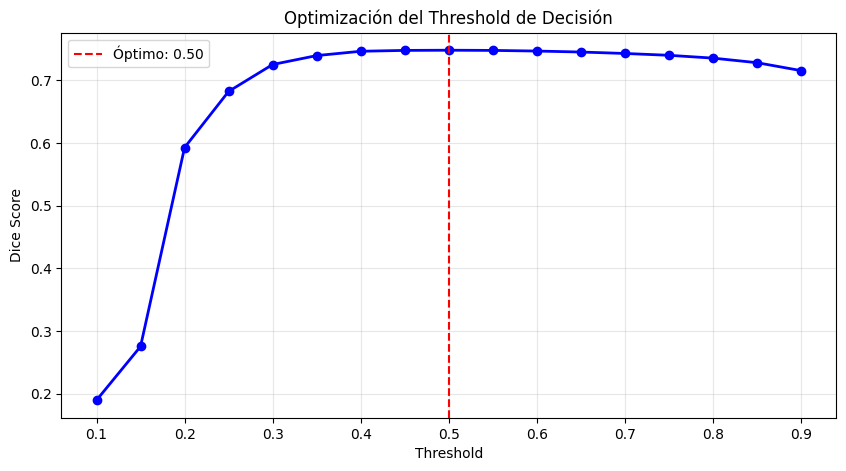

Mejor Threshold encontrado: 0.50 con Dice: 0.7482
=== CHECKPOINT P9.1 ✔ (gráfica threshold vs dice con el óptimo marcado) ===


In [15]:
# ============================================================
# TAREA 9.1: BÚSQUEDA DEL THRESHOLD ÓPTIMO  ✔ SOLUCIÓN
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 0.95, 0.05)
val_dices_per_threshold = []

model.eval()
for threshold in thresholds:
    epoch_dice = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            intersection = (preds * masks).sum()
            union = preds.sum() + masks.sum()
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
            epoch_dice += dice.item()

    avg_dice = epoch_dice / len(val_loader)
    val_dices_per_threshold.append(avg_dice)
    print(f"   Threshold {threshold:.2f} -> Dice: {avg_dice:.4f}")

best_idx = int(np.argmax(val_dices_per_threshold))
best_threshold = thresholds[best_idx]
max_dice = val_dices_per_threshold[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, val_dices_per_threshold, marker='o', color='b', linewidth=2)
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Óptimo: {best_threshold:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Dice Score')
plt.title('Optimización del Threshold de Decisión')
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Mejor Threshold encontrado: {best_threshold:.2f} con Dice: {max_dice:.4f}")
print("=== CHECKPOINT P9.1 ✔ (gráfica threshold vs dice con el óptimo marcado) ===")


## Bloque 9.2: Leer los Errores de un Modelo de Segmentación
### Por qué una media no basta

Un Dice promedio de 0.80 en validación puede estar compuesto de muchas formas distintas: 100 imágenes con Dice 0.80 cada una, o 90 imágenes con Dice 0.95 y 10 imágenes con Dice 0.05. La media no distingue estos dos escenarios, pero clínicamente son radicalmente distintos — el segundo caso significa que hay un subgrupo de pacientes donde el modelo falla por completo, oculto detrás de un buen promedio general.

### TP, TN, FP y FN a nivel de píxel

Hasta ahora habéis calculado Dice e IoU como fórmulas sobre conjuntos de píxeles, sin nombrar explícitamente sus cuatro componentes. En segmentación, cada píxel de la máscara predicha cae en una de estas cuatro categorías al compararlo con el ground truth:

| | GT = tumor | GT = fondo |
|---|---|---|
| **Predicción = tumor** | TP (acierto) | FP (falsa alarma) |
| **Predicción = fondo** | FN (fallo, no lo detecta) | TN (acierto) |

En una imagen **normal** (máscara real completamente vacía, sin ningún píxel de tumor), es matemáticamente imposible tener TP o FN — no hay tumor que acertar ni que perder. Los únicos resultados posibles son TN (todo el fondo correctamente ignorado) o FP (el modelo "alucina" un tumor donde no existe). Por eso el Caso 1 de esta tarea (una imagen normal) es la comprobación más directa y limpia de si vuestro modelo genera Falsos Positivos.

### Por qué elegir los casos a propósito, y no al azar

El dataset BUSI está desbalanceado (437 benign, 210 malignant, 133 normal). Si eligierais 5 imágenes puramente al azar del `val_df`, lo más probable es que las 5 sean `benign` — la clase mayoritaria — y nunca lleguéis a ver cómo se comporta el modelo con imágenes `normal` o `malignant`. Es el mismo problema del split del Bloque 7.1, aplicado ahora a la inspección visual: un muestreo aleatorio ciego a las clases minoritarias no os enseña nada sobre ellas. Por eso la tarea pide explícitamente un caso de cada clase, y no "5 imágenes cualquiera".

### Cómo encontrar los "fallos estrepitosos" sin depender de la suerte

Para los Casos 4 y 5, la instrucción permite buscar "iterando" en vez de al azar. La forma sistemática de hacerlo es: calcular el Dice individual de cada imagen de `val_df` (no el promedio, uno por imagen),
y ordenar de menor a mayor. Las imágenes con el Dice más bajo son, por definición, aquelca más — encontrarlas por fuerza bruta es mucho más fiable que confiar en que os toquenpor azar en una muestra aleatoria pequeña.

### Qué mirar en el overlay

El overlay (predicción en rojo sobre la imagen original) es donde se ve el *tipo* de error, no solo si hubo error:

| Patrón visual | Tipo de error | Efecto en Dice |
|-----------------|-----------------|-------------------|
| Rojo se queda corto respecto al contorno real del tumor | Bajo-segmentación (FN en el borde) | Reduce Dice |
| Rojo se extiende más allá del contorno real | Sobre-segmentación (FP en el borde) | Reduce Dice |
| Rojo aparece sobre tejido sano sin tumor cerca | Falso Positivo "alucinado" | Reduce Dice y es clínicamente grave |
| No hay rojo donde sí hay tumor | Falso Negativo total | El error más grave clínicamente |

### De lo técnico a lo clínico

El checkpoint no pide solo identificar TP/TN/FP/FN — pide explicar **qué significa clínicamente** cada tipo de error. No es lo mismo decir "hay píxeles FP en el borde superior" que decir "el modelo marcaría una zona sana como sospechosa, lo que llevaría a pruebas o biopsias innecesarias en esta paciente". La segunda frase es la que conecta con el dilema FP/FN de la introducción de esta práctica.

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Media vs casos individuales | Un buen Dice promedio puede ocultar fallos graves en subgrupos concretos |
| TP/TN/FP/FN por píxel | En imágenes normales solo son posibles TN o FP — nunca TP ni FN |
| Selección deliberada | Muestreo aleatorio en datos desbalanceados esconde las clases minoritarias |
| Buscar fallos | Ordenar por Dice individual, no confiar en el azar |
| Overlay | El patrón visual (falta, sobra, o aparece donde no debería) indica el tipo de error |
| Explicación clínica | Traducir TP/FP/FN a consecuencias reales para la paciente |

## Tarea 9.2: Análisis Cualitativo de Errores
Las métricas numéricas no lo cuentan todo. Un Dice de 0.80 puede ocultar errores graves en casos clínicamente relevantes. Vamos a visualizar **dónde** está fallando el modelo.

### Instrucciones:
1. Selecciona manualmente (o aleatoriamente) 5 imágenes del `val_df` que representen:
   * **Caso 1:** Una imagen de clase **"normal"** (para ver si hay Falsos Positivos).
   * **Caso 2:** Una imagen de clase **"benign"** con tumor pequeño.
   * **Caso 3:** Una imagen de clase **"malignant"** con bordes irregulares.
   * **Caso 4 y 5:** Dos imágenes donde el modelo haya fallado estrepitosamente (puedes buscarlas iterando si quieres, o usar aleatorias).
2. Para cada una, genera una figura con 4 columnas:
   * **Original**
   * **Ground Truth (Máscara Real)**
   * **Predicción** (usando tu `best_threshold`)
   * **Overlay** (Predicción en rojo sobre la Original)
3. Añade un título a cada imagen indicando su clase y si es TP, TN, FP o FN.

> **CHECKPOINT P9.1:** Muestra al profesor las 5 imágenes y explica clínicamente qué está pasando en los errores.

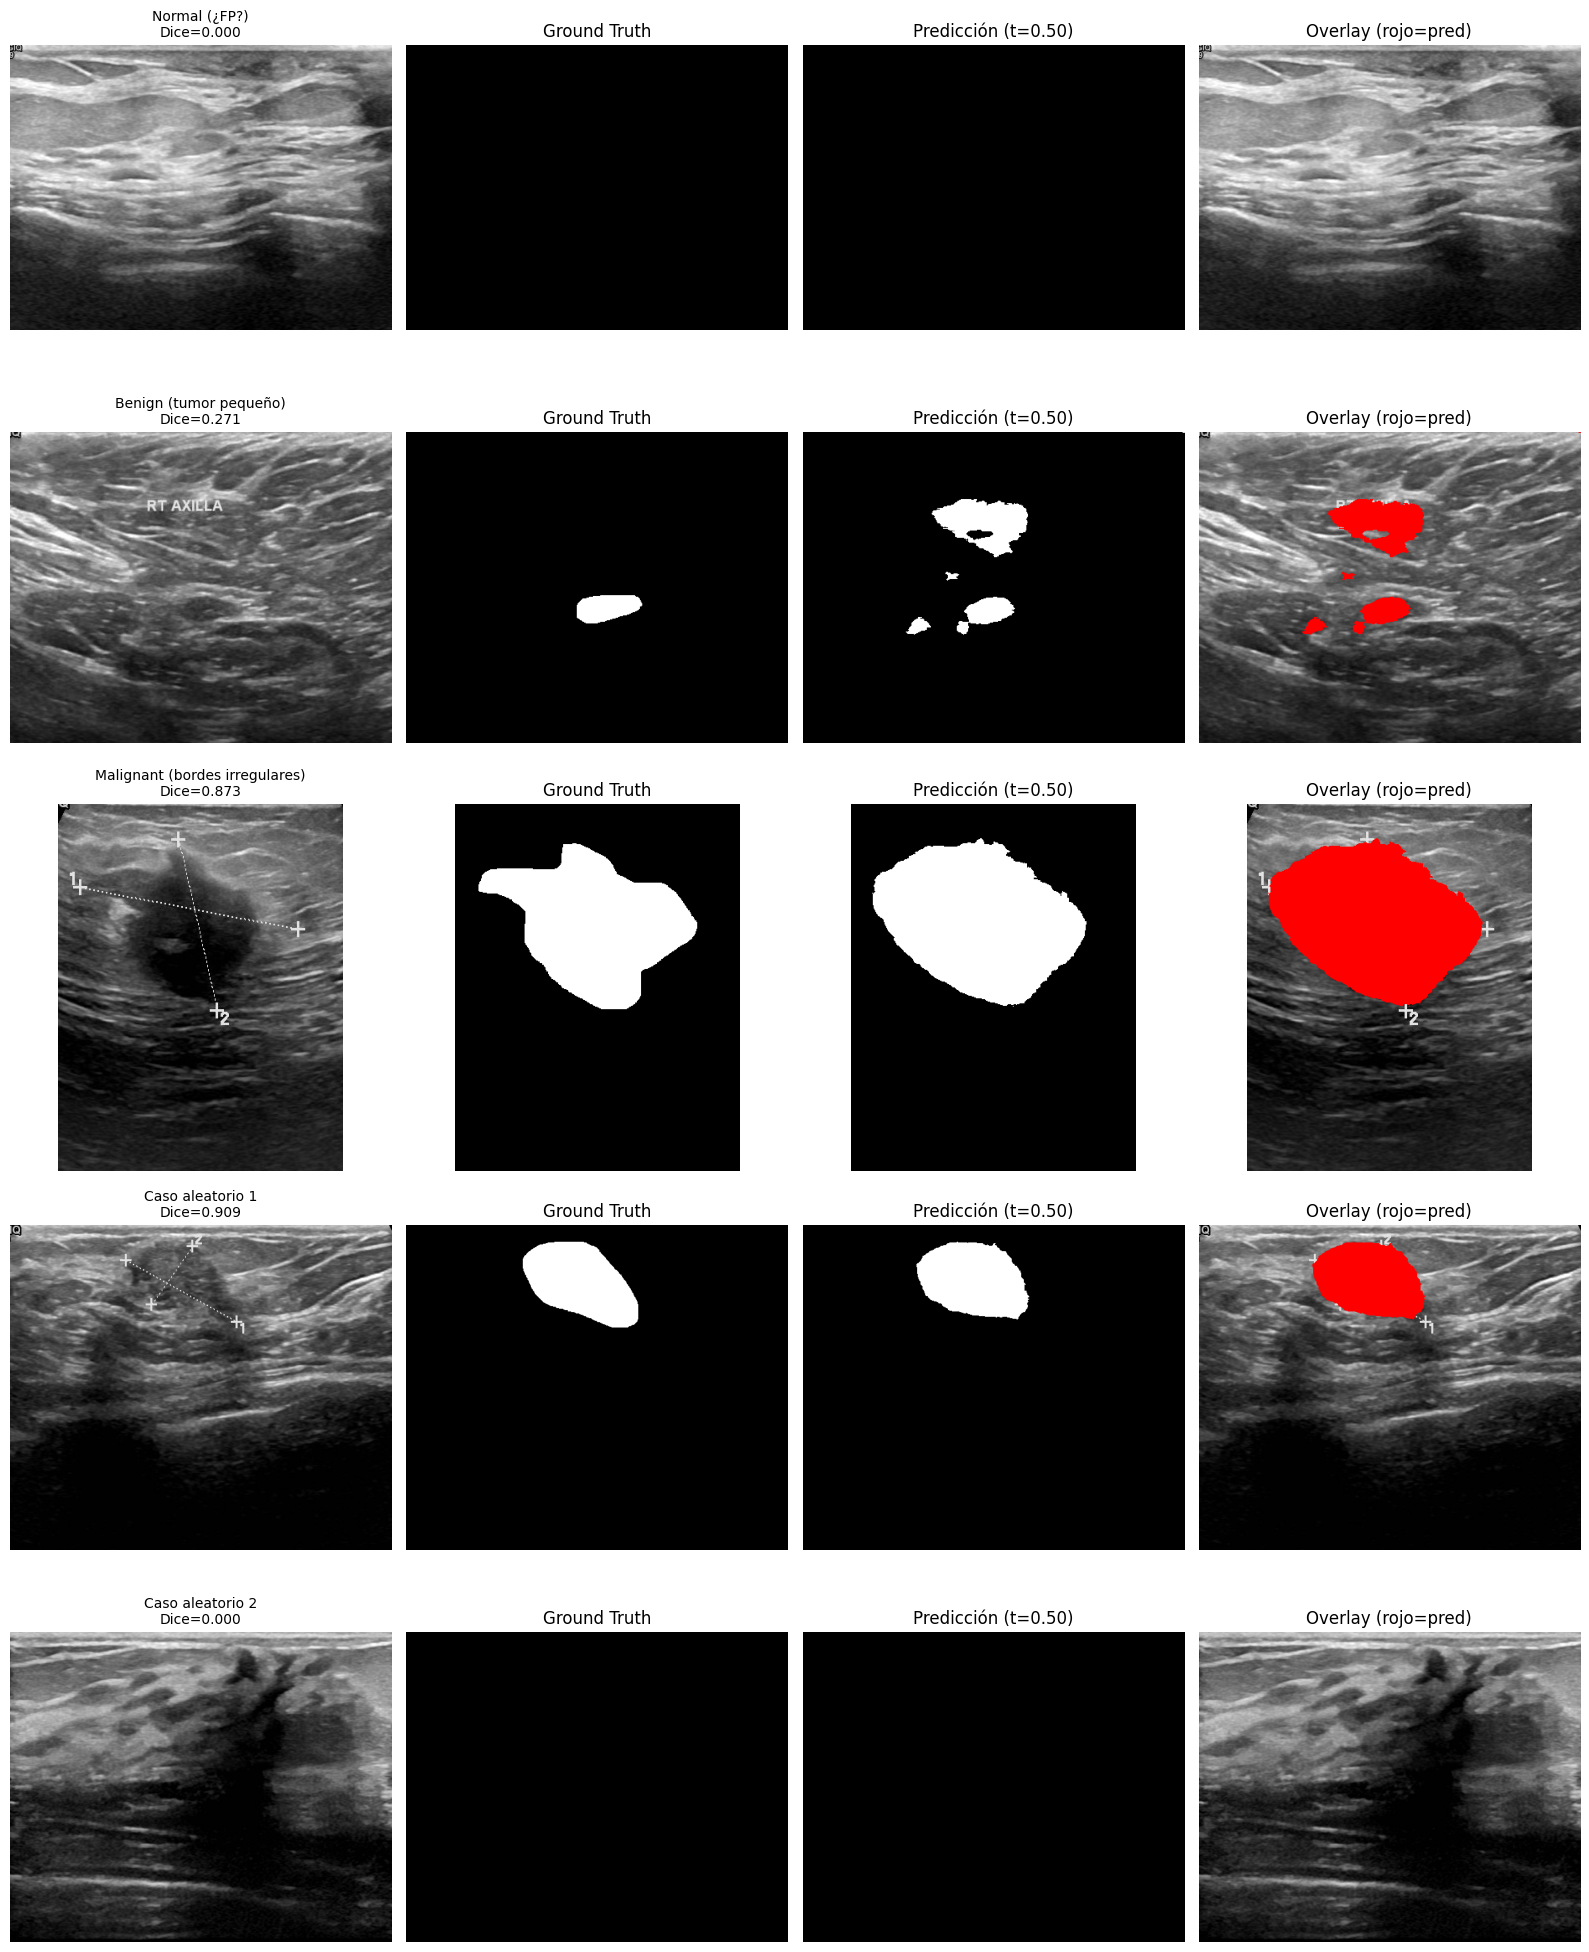

=== CHECKPOINT P9.2 ✔ (5 casos críticos con overlay) ===


In [16]:
# ============================================================
# TAREA 9.2: ANÁLISIS CUALITATIVO DE ERRORES  ✔ SOLUCIÓN
# ============================================================
import cv2

def predict_mask(model, image_rgb, threshold):
    """Máscara binaria en el tamaño ORIGINAL (reescala probabilidades y umbraliza al final)."""
    h, w = image_rgb.shape[:2]
    img = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = (img - mean) / std
    t = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.sigmoid(model(t))
    probs = cv2.resize(probs.float().squeeze().cpu().numpy(), (w, h))
    return (probs > threshold).astype(np.uint8)

# 5 casos: 1 normal (¿FP?), 1 benign pequeño, 1 malignant irregular y 2 fallos/aleatorios
idx_normal = val_df[val_df['class'] == 'normal'].index[0]
idx_benign = val_df[val_df['class'] == 'benign'].index[0]
idx_malig = val_df[val_df['class'] == 'malignant'].index[0]
idxs_rand = val_df.sample(2, random_state=7).index.tolist()

selected = [(idx_normal, 'Normal (¿FP?)'), (idx_benign, 'Benign (tumor pequeño)'),
            (idx_malig, 'Malignant (bordes irregulares)'),
            (idxs_rand[0], 'Caso aleatorio 1'), (idxs_rand[1], 'Caso aleatorio 2')]

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
model.eval()

for row_idx, (idx, title) in enumerate(selected):
    row = val_df.loc[idx]

    img = cv2.imread(row['image_path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask_gt = np.zeros(img_rgb.shape[:2], dtype=np.uint8)
    if row['mask_path'] and Path(row['mask_path']).exists():
        mask_gt = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
    mask_gt_bin = (mask_gt > 127).astype(np.uint8)

    pred = predict_mask(model, img_rgb, best_threshold)

    d = dice_score(torch.tensor(pred).float(), torch.tensor(mask_gt_bin).float()).item()

    axes[row_idx, 0].imshow(img_rgb); axes[row_idx, 0].set_title(f"{title}\nDice={d:.3f}", fontsize=10); axes[row_idx, 0].axis('off')
    axes[row_idx, 1].imshow(mask_gt_bin, cmap='gray'); axes[row_idx, 1].set_title("Ground Truth"); axes[row_idx, 1].axis('off')
    axes[row_idx, 2].imshow(pred, cmap='gray'); axes[row_idx, 2].set_title(f"Predicción (t={best_threshold:.2f})"); axes[row_idx, 2].axis('off')
    overlay = img_rgb.copy(); overlay[pred == 1] = [255, 0, 0]
    axes[row_idx, 3].imshow(overlay); axes[row_idx, 3].set_title("Overlay (rojo=pred)"); axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.show()
print("=== CHECKPOINT P9.2 ✔ (5 casos críticos con overlay) ===")


## Bloque 9.3: Cerrar el Círculo — De la Calibración a la Submission
### El mismo tipo de pipeline que ya construisteis en la Práctica 7

Esta tarea os pide repetir, conceptualmente, el mismo pipeline de inferencia del Bloque 7.4: cargar imagen de test, preprocesarla igual que en entrenamiento, pasarla por el modelo, umbralizar, redimensionar la máscara al tamaño original, convertir a RLE y guardar el CSV. Lo único que cambia es **qué valor de threshold usáis para binarizar**: antes era `0.5` fijo, ahora es vuestro `best_threshold` calibrado en la Tarea 1.

> **Idea clave:** si os encontráis reescribiendo todo el preprocesamiento desde cero, parad un momento — es prácticamente el mismo código que ya escribisteis en la Práctica 7, con un único valor distinto.

### Cerrando el círculo del threshold

En el Bloque 9.1 calibrasteis `best_threshold` usando el conjunto de **validación** — precisamente porque no podíais usar train (sesgado) ni test (no tenéis sus máscaras para medir Dice ahí). Ahora, en la Tarea 9.3, ese mismo valor fijo se aplica al conjunto de **test**, sin volver a recalcularlo. Este es el ciclo completo y correcto de un hiperparámetro: se calibra una vez en validación, y ese valor congelado es el que se despliega sobre datos nuevos.

> **Idea clave:** si en este punto os encontrarais recalculando el threshold sobre el propio test, estaríais repitiendo exactamente el error que el Bloque 9.1 os explicó por qué evitar.

### Un matiz técnico antes de redimensionar la máscara

El modelo predice siempre a resolución `IMG_SIZE`, pero cada imagen de test tiene su propio tamaño original — así que en algún momento tendréis que redimensionar la máscara predicha de vuelta a `(original_h, original_w)`, igual que en la Práctica 7.

Aquí hay un detalle que conviene tener claro **antes** de escribir el código, porque es un bug fácil de cometer sin que salte ningún error: si redimensionáis una máscara que **ya es binaria** (solo ceros y unos) con `cv2.resize`, la interpolación por defecto puede mezclar valores en los bordes del tumor, dejando píxeles con valores intermedios (ni 0 ni 1):

```
máscara binaria pequeña (IMG_SIZE)  →  cv2.resize  →  ya no es puramente 0/1 en los bordes
```

Tenéis dos formas válidas de evitarlo:

1. **Binarizar, redimensionar, y volver a binarizar**: aplicáis el threshold a `IMG_SIZE`, redimensionáis esa máscara, y aplicáis un segundo corte (por ejemplo `> 0.5`) después del resize para limpiar los valores intermedios que introdujo la interpolación.
2. **Redimensionar las probabilidades, binarizar una sola vez**: redimensionáis la salida continua de `sigmoid()` (no la máscara binaria) al tamaño original, y aplicáis `best_threshold` una única vez, ya en la resolución final.

Cualquiera de las dos es correcta. Lo que **no** es correcto es redimensionar una máscara binaria y pasársela directamente a `mask_to_rle` sin ese segundo corte — el RLE resultante tendría límites de tumor ligeramente distintos a los que vuestro modelo predijo realmente, sin que nada en la ejecución os avise del problema.

### Por qué un nombre de archivo distinto

La tarea pide guardar `submission_final.csv`, no sobrescribir el `submission.csv` de la Práctica 7. Mantener nombres distintos por versión os permite comparar en el Leaderboard de Kaggle qué mejora concreta aportó cada paso (baseline → augmentation → threshold óptimo), en vez de perder esa trazabilidad sobrescribiendo el mismo fichero cada vez.

### El pipeline completo, de un vistazo

```
P7: Modelo entrenado (threshold fijo 0.5)
        │
P8: ¿Mejora con augmentation?  →  modelo definitivo
        │
Bloque 9.1: best_threshold calibrado en validación
        │
Tarea 9.3: modelo definitivo + best_threshold  →  submission_final.csv
```

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Reutilización | El pipeline es conceptualmente el del Bloque 7.4; solo cambia el threshold usado |
| Ciclo del hiperparámetro | Se calibra una vez en validación, se aplica fijo sobre test |
| Binarizar vs redimensionar | Redimensionar una máscara ya binaria reintroduce valores intermedios; hay que re-binarizar o redimensionar las probabilidades antes de umbralizar |
| Nombrado de ficheros | Versionar las submissions permite atribuir la mejora a cada cambio concreto |

## Tarea 9.3: Generación de la Submission Final
Ha llegado el momento de la verdad. Vamos a aplicar todo lo aprendido (mejor modelo, mejor threshold) al conjunto de test para generar nuestro `submission.csv` definitivo.

### Instrucciones:
1. Itera sobre todas las imágenes de la carpeta `test/images`.
2. Preprocesa cada imagen exactamente igual que en la Tarea 9.2.
3. Predice la máscara usando el **`best_threshold`** que encontraste en la Tarea 9.1.
4. Redimensiona la máscara al tamaño original de la imagen.
5. Convierte la máscara a formato **RLE** (usando la función `mask_to_rle` de la P6).
6. Guarda los resultados en un DataFrame y expórtalo como **`submission_final.csv`**.

> **CHECKPOINT P9.2:** Descarga el `submission_final.csv`, súbelo a Kaggle y muestra al profesor tu nueva puntuación en el Leaderboard. ¡A por el top 10!

In [17]:
# ============================================================
# TAREA 9.3: GENERACIÓN DE LA SUBMISSION FINAL  ✔ SOLUCIÓN
# ============================================================
import os
import pandas as pd

test_images = find_test_images()
results = []

print(f"Generando submission final con threshold = {best_threshold:.2f}...")
print(f"Total de imágenes de test: {len(test_images)}")

model.eval()
with torch.no_grad():
    for idx, img_path in enumerate(test_images):
        # 1. Cargar y preprocesar (igual que en entrenamiento)
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_norm = img_resized.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_norm = (img_norm - mean) / std
        img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        # 2. Predecir con best_threshold (reescalar PROBABILIDADES y umbralizar al final)
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)
        probs = probs.float().squeeze().cpu().numpy()
        probs_resized = cv2.resize(probs, (original_w, original_h))
        mask_binary = (probs_resized > best_threshold).astype(np.uint8)

        # 3. Convertir a RLE y guardar (incluye dimensiones originales por si el sample las pide)
        rle = mask_to_rle(mask_binary)
        results.append({'Id': img_path.name, 'Expected': rle,
                        'Height': original_h, 'Width': original_w})

        if (idx + 1) % 50 == 0:
            print(f"   Progreso: {idx + 1}/{len(test_images)} imágenes")

submission_df = pd.DataFrame(results)
assert 'Id' in submission_df.columns and len(submission_df) > 0, "No se generaron predicciones"
n_tumor = int((submission_df['Expected'] != '').sum())
submission_df = align_submission(submission_df)   # adapta al formato exacto de sample_submission.csv
submission_df.to_csv('submission_final.csv', index=False)

print(f"submission_final.csv generado correctamente: {len(submission_df)} filas ({n_tumor} con tumor). ¡Súbelo a Kaggle!")
print("=== CHECKPOINT P9.3 ✔ (submission_final.csv) ===")


Generando submission final con threshold = 0.50...
Total de imágenes de test: 234
   Progreso: 50/234 imágenes
   Progreso: 100/234 imágenes
   Progreso: 150/234 imágenes
   Progreso: 200/234 imágenes
submission_final.csv generado correctamente: 234 filas (223 con tumor). ¡Súbelo a Kaggle!
=== CHECKPOINT P9.3 ✔ (submission_final.csv) ===


# Práctica 10: TTA, Submission Final y Defensa del Proyecto
## Sesión única (30 Nov Grupo A / 2 Dic Grupo B)

### Objetivos de la sesión:
1. Implementar **Test Time Augmentation (TTA)** para mejorar la robustez de las predicciones en el conjunto de test.
2. Generar la **Submission Final** definitiva para el Leaderboard de Kaggle.
3. Estructurar y ensayar la **Defensa Oral** del proyecto.

### El "Truco" de Kaggle: TTA
En competiciones reales, el modelo no solo predice una vez. Se le pasa la imagen original, su versión volteada, y a veces rotada. Luego se promedian las probabilidades. Esto reduce la varianza y suele subir el Dice Score entre un 1% y un 3%.

> **CHECKPOINT P10:** Mostrar al profesor:
> 1. El código de TTA funcionando.
> 2. La captura de pantalla de vuestra posición final en el Leaderboard de Kaggle.
> 3. El esquema de vuestra presentación oral.

## Bloque 10.1: Test Time Augmentation — el Reverso de Data Augmentation
### TTA es la contrapartida de Data Augmentation, pero en inferencia

En la Práctica 8 entrenasteis con `HorizontalFlip(p=0.5)` para forzar al modelo a ser **invariante** al volteo horizontal: que aprenda que un tumor sigue siendo el mismo tumor, esté en el lado izquierdo o en el derecho de la imagen. TTA explota esa invarianza aprendida, pero en el momento de predecir, no de entrenar:

| | Data Augmentation (P8) | Test Time Augmentation (P10) |
|---|---|---|
| ¿Cuándo se aplica? | Durante el entrenamiento | Durante la inferencia |
| ¿Qué transforma? | Las imágenes de entrenamiento | La imagen de test, varias veces |
| ¿Qué consigue? | Que el modelo *aprenda* a ser invariante | Aprovechar esa invarianza para *promediar* varias opiniones del mismo modelo |
| ¿Cambian los pesos? | Sí, se entrena con ellos | No, el modelo ya está fijo |

> **Idea clave:** si el modelo nunca vio ejemplos volteados horizontalmente durante el entrenamiento, no hay ninguna razón para esperar que su predicción sobre la imagen volteada sea fiable — TTA solo funciona porque la Práctica 8 preparó al modelo para esto.

### Por qué hay que deshacer el flip de la predicción antes de promediar

Cuando volteáis la imagen de entrada y la pasáis por el modelo, la máscara que obtenéis también sale volteada: un tumor que en la imagen original está a la izquierda, en la predicción sobre la imagen volteada aparece "a la derecha" del lienzo. Si promediarais esa predicción directamente con la original (sin devolverla a su orientación), estaríais mezclando el píxel `(x, y)` de una con el píxel `(ancho - x, y)` de la otra — dos posiciones que no representan el mismo punto de la imagen. Por eso el algoritmo pide explícitamente voltear la predicción de vuelta **antes** del promedio: es el mismo principio del Bloque 7.1 (una transformación geométrica debe deshacerse de forma simétrica para que las cosas sigan alineadas).

### Promediar probabilidades, no máscaras ya binarizadas

Fijaos en el orden exacto del algoritmo: `probs_final = (probs_orig + probs_flip) / 2`, y **solo después** se aplica `best_threshold`. Esto no es casualidad — es el mismo principio de "umbralizar una sola vez, al final" que visteis en la Práctica 9. Si primero binarizarais cada predicción por separado y luego promediarais dos máscaras de 0s y 1s, perderíais la información de *cuánta confianza* tenía cada vista: un píxel donde una vista dice 0.9 y la otra 0.6 (tumor claro en ambas) y otro donde una dice 0.51 y la otra 0.49 (frontera dudosa) pueden dar el mismo resultado si binarizáis antes de promediar, pero son situaciones muy distintas si promediáis las probabilidades primero.

### El coste de TTA: tiempo de inferencia, no de entrenamiento

Data Augmentation y TTA tienen el coste computacional en lados opuestos del proceso:

| Técnica | Dónde cuesta más tiempo |
|---------|----------------------------|
| Data Augmentation | Entrenamiento (cada época procesa variaciones distintas) |
| TTA | Inferencia (cada imagen de test se predice 2 veces: original + volteada) |

Con 234 imágenes de test y solo 2 vistas por imagen, el coste extra es asumible en Colab. Si en vez de 1 flip usarais 4 u 8 transformaciones distintas, el tiempo de inferencia crecería proporcionalmente — TTA es una decisión de compromiso entre tiempo disponible y mejora esperada de Dice.

### Por qué horizontal flip y no cualquier otra transformación

En el Bloque 8.1 establecisteis que una rotación de 90° o un flip vertical no son transformaciones clínicamente válidas para ecografía mamaria (cambian la orientación anatómica de forma que nunca ocurriría en una adquisición real) — y por eso el pipeline de augmentation nunca las usó. La misma regla se aplica aquí: TTA solo debería usar transformaciones con las que el modelo **fue entrenado a convivir**. Aplicar TTA con una rotación de 90°, por ejemplo, promediaría una predicción fiable (la original) con una predicción sobre una entrada que el modelo nunca aprendió a interpretar — en el mejor de los casos no ayuda, en el peor, empeora el resultado.

> **Pregunta para pensar:** el enunciado dice que el TTA "suele" subir el Dice entre un 1% y un 3%, no que lo garantice siempre. Según lo anterior, ¿en qué circunstancia concreta esperaríais que el TTA con flip horizontal *no* mejorase, o incluso empeorase el resultado?

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| TTA vs Data Augmentation | DA entrena invarianza; TTA la explota en inferencia, sin tocar los pesos |
| Deshacer el flip | La predicción sobre la imagen volteada también sale volteada; hay que revertirla antes de comparar píxel a píxel |
| Promediar antes de umbralizar | Promediar probabilidades conserva matices de confianza que promediar máscaras binarias pierde |
| Coste | Tiempo extra en inferencia (proporcional al nº de vistas), no en entrenamiento |
| Transformaciones válidas | Solo las que el modelo vio durante el entrenamiento (Bloque 8.1) |

## Tarea 10.1: Implementación de Test Time Augmentation (TTA)
### ¿Qué es el TTA?
Durante el entrenamiento usamos *Data Augmentation* para que el modelo vea más datos.
Durante la inferencia (test), usamos *Test Time Augmentation* para que el modelo "vea" la misma imagen desde diferentes perspectivas y promedie su confianza.

### El algoritmo:
1. Tomar la imagen original de test.
2. Predecir la máscara de probabilidad (`probs_orig`).
3. Voltear la imagen horizontalmente (`flip_img`).
4. Predecir la máscara de la imagen volteada (`probs_flip`).
5. Voltear la predicción de vuelta a la orientación original.
6. **Promediar**: `probs_final = (probs_orig + probs_flip) / 2`.
7. Aplicar el `best_threshold` sobre `probs_final`.

### Instrucciones:
1. Define una función `predict_with_tta(model, img_tensor, device, threshold)`.
2. Dentro, haz la predicción normal.
3. Aplica `torch.flip(img_tensor, [-1])` para voltear la imagen.
4. Haz la segunda predicción y vuelve a voltear el resultado con `torch.flip()`.
5. Promedia ambas salidas y binariza con el umbral.

In [18]:
# ============================================================
# TAREA 10.1: FUNCIÓN DE INFERENCIA CON TTA  ✔ SOLUCIÓN
# ============================================================

def predict_with_tta(model, img_tensor, device, threshold=0.5):
    """
    Realiza inferencia usando Test Time Augmentation (Horizontal Flip).
    Promedia las probabilidades de la imagen original y su versión volteada.
    """
    model.eval()
    with torch.no_grad():
        # 1. Predicción original
        logits_orig = model(img_tensor)
        probs_orig = torch.sigmoid(logits_orig)

        # 2. Voltear imagen y predecir
        img_flipped = torch.flip(img_tensor, [-1])
        logits_flip = model(img_flipped)
        probs_flip = torch.sigmoid(logits_flip)

        # 3. Voltear la predicción de vuelta a la orientación original
        probs_flip_restored = torch.flip(probs_flip, [-1])

        # 4. Promediar (antes de umbralizar) y binarizar
        probs_final = (probs_orig + probs_flip_restored) / 2.0
        mask_pred = (probs_final > threshold).float()

    return mask_pred

print("Función TTA definida")


Función TTA definida


## Bloque 10.2: Los Últimos Detalles Antes de la Submission Definitiva
### Por qué `dtype=torch.float32` es "CLAVE"

El código marca explícitamente `torch.tensor(img_norm, dtype=torch.float32)`. Esto no es una precaución genérica — sin ello, os encontraríais con un error real y bastante críptico la primera vez que os pase.

`numpy` usa `float64` (doble precisión) por defecto en muchas operaciones aritméticas, mientras que los pesos de vuestro modelo son `float32` (precisión simple) — es el estándar en redes neuronales, porque duplicar la precisión no mejora el resultado y sí duplica la memoria usada. Si construís el tensor de entrada sin fijar el dtype y `numpy` os cuela un `float64` en algún paso intermedio, PyTorch os devolverá algo como `RuntimeError: expected scalar type Float but found Double` en la primera capa convolucional — el modelo no puede multiplicar pesos `float32` por una entrada `float64`.

> **Idea clave:** fijar `dtype=torch.float32` explícitamente al crear el tensor es más seguro que confiar en que todas las operaciones previas (`.astype(np.float32)`, restas, divisiones) mantengan la precisión que esperáis en cada paso.

### Anidar `torch.no_grad()` no es un error

El comentario `# Opcional, ya lo maneja la función, pero buena práctica` señala algo real: `predict_with_tta` ya envuelve su contenido en `torch.no_grad()` (Tarea 10.1). Poner un segundo `with torch.no_grad():` alrededor de la llamada, en el bucle de esta tarea, es redundante pero **no es un error** — los gestores de contexto de PyTorch se pueden anidar sin problema; el segundo `no_grad()` simplemente confirma una condición que ya estaba activa. Es una práctica defensiva razonable: si en el futuro alguien modifica `predict_with_tta` y olvida el `no_grad()` interno, el externo seguiría protegiendo el bucle de inferencia.

### El resize y el segundo threshold, una vez más

En la sección de post-procesado (`mask_resized = cv2.resize(mask_np, ...)` seguido de `mask_binary = (mask_resized > 0.5)`) reconoceréis exactamente el patrón del Bloque 9.3: `predict_with_tta` os devuelve una máscara ya binarizada a resolución `IMG_SIZE`; al redimensionarla al tamaño original con `cv2.resize`, la interpolación reintroduce valores intermedios en los bordes, y por eso hace falta ese segundo `> 0.5` antes de pasarla a `mask_to_rle`. El patrón no cambia por usar TTA — solo cambia que la máscara que redimensionáis ahora viene de promediar dos vistas en vez de una.

### El recorrido completo de una submission

A estas alturas, cada submission que habéis subido a Kaggle representa una capa más sobre la anterior:

```
submission.csv          (P7):  modelo baseline, threshold fijo 0.5
submission_final.csv    (P9):  mejor modelo + best_threshold calibrado
submission_TTA.csv      (P10): mejor modelo + best_threshold + promedio de 2 vistas (TTA)
```

Cada fichero debería, en principio, superar (o al menos igualar) al anterior en el Leaderboard — si no es así, es una señal útil para la Tarea 9.3 (revisar qué está fallando) más que algo que ocultar en la defensa oral.

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| `dtype=torch.float32` | Evita el error de mezclar `float64` (numpy) con los pesos `float32` del modelo |
| `torch.no_grad()` anidado | Seguro y redundante, no un error — refuerza una protección que ya existía |
| Resize + segundo threshold | Mismo patrón del Bloque 9.3: la interpolación reintroduce valores intermedios en los bordes |
| Progresión de submissions | Cada CSV añade una mejora sobre el anterior: baseline → threshold óptimo → TTA |

## Tarea 10.2: Generación de la Submission Final con TTA
Es el momento de la verdad. Vamos a usar la función TTA para generar nuestro último `submission.csv`.

### Instrucciones:
1. Itera sobre las imágenes de `test/images`.
2. Preprocesa la imagen (recuerda el `dtype=torch.float32` para evitar errores de tipo).
3. Llama a `predict_with_tta()` usando vuestro `best_threshold`.
4. Redimensiona la máscara al tamaño original y conviértela a RLE.
5. Guarda el DataFrame como **`submission_TTA.csv`** y súbelo a Kaggle.

> **Pista:** El TTA duplica el tiempo de inferencia, pero en un dataset de 234 imágenes en Colab solo tardará unos minutos extra. ¡Merece la pena!

> **CHECKPOINT P10.1:** Descarga `submission_TTA.csv` y súbelo a Kaggle. Muestra al profesor tu nueva posición en el Leaderboard.

In [19]:
# ============================================================
# TAREA 10.2: SUBMISSION FINAL CON TTA  ✔ SOLUCIÓN
# ============================================================
import pandas as pd

test_images = find_test_images()
results = []

print(f"Generando Submission Final con TTA (Threshold = {best_threshold:.2f})...")
print(f"Total imágenes: {len(test_images)}")

with torch.no_grad():  # Opcional (ya lo maneja la función), pero buena práctica
    for idx, img_path in enumerate(test_images):
        # 1. Cargar y preprocesar (CLAVE: dtype=torch.float32)
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        img_norm = img_resized.astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_norm = (img_norm - mean) / std

        img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        # 2. Predecir con TTA
        mask_pred = predict_with_tta(model, img_tensor, DEVICE, threshold=best_threshold)

        # 3. Post-procesar y RLE (segundo umbral tras el resize)
        mask_np = mask_pred.squeeze().cpu().numpy()
        mask_resized = cv2.resize(mask_np, (original_w, original_h))
        mask_binary = (mask_resized > 0.5).astype(np.uint8)
        rle = mask_to_rle(mask_binary)
        results.append({'Id': img_path.name, 'Expected': rle,
                        'Height': original_h, 'Width': original_w})

        if (idx + 1) % 50 == 0:
            print(f"   Progreso: {idx + 1}/{len(test_images)}")

submission_df = pd.DataFrame(results)
assert 'Id' in submission_df.columns and len(submission_df) > 0, "No se generaron predicciones"
n_tumor = int((submission_df['Expected'] != '').sum())
submission_df = align_submission(submission_df)   # adapta al formato exacto de sample_submission.csv
submission_df.to_csv('submission_TTA.csv', index=False)

print(f"¡Submission Final generada! (submission_TTA.csv) — {len(submission_df)} filas ({n_tumor} con tumor)")
print("=== CHECKPOINT P10.1 ✔ (submission_TTA.csv) ===")


Generando Submission Final con TTA (Threshold = 0.50)...
Total imágenes: 234
   Progreso: 50/234
   Progreso: 100/234
   Progreso: 150/234
   Progreso: 200/234
¡Submission Final generada! (submission_TTA.csv) — 234 filas (210 con tumor)
=== CHECKPOINT P10.1 ✔ (submission_TTA.csv) ===


## Bloque 10.3: Preparar las Preguntas, no Solo las Diapositivas
### Por qué la defensa oral pesa tanto como el código

Un modelo que funciona pero que su autor no puede explicar es, en la práctica profesional, un modelo que no se puede defender ante un comité ético, un radiólogo escéptico o un revisor de un artículo científico. La defensa oral no es un trámite añadido al final del proyecto — es la comprobación de que entendisteis las decisiones que tomasteis, no solo que copiasteis código que funciona.

### La pregunta que rompe una defensa poco preparada: "¿por qué?"

Los criterios de evaluación piden "pensamiento crítico: no solo leer números, sino explicar por qué el modelo falla o acierta". En la práctica, esto se traduce en que el profesor no va a preguntar "¿qué Dice Score obtuvisteis?" (eso ya está en la pantalla) sino "¿por qué ese threshold y no 0.5?", "¿por qué esta imagen falla y esta otra no?". Si solo memorizáis los resultados sin entender las decisiones detrás, esas preguntas os van a pillar en blanco delante del profesor — que es exactamente el momento que cuenta para la nota.

### Batería de preguntas para poneros a prueba antes de la defensa

Repasad estas preguntas por vuestra cuenta antes de la defensa. Cada una se corresponde con un Bloque que ya habéis trabajado — si no sabéis responderla con seguridad, es el bloque que os conviene releer:

| Pregunta | Bloque donde está la respuesta |
|----------|-----------------------------------|
| ¿Por qué normalizáis con media/std de ImageNet y no solo dividiendo por 255? | Bloque 7.1 (Dataset y DataLoader) |
| ¿Por qué la función de pérdida combina Dice + BCE en vez de usar solo una? | Bloque 7.2 (U-Net y Función de Pérdida) |
| ¿Qué diferencia hay entre `model.train()` y `model.eval()`, y por qué importa? | Bloque 7.3 (Bucle de Entrenamiento) |
| ¿Por qué no podéis calcular vuestro Dice real sobre el conjunto de test? | Bloque 7.4 (De Entrenamiento a Submission) |
| ¿Por qué una rotación de 90° no es una augmentation válida aquí? | Bloque 8.1 (Data Augmentation) |
| ¿Por qué hay que "desnormalizar" la imagen para poder visualizarla? | Bloque 8.2 (Verificar Visualmente) |
| ¿Por qué reinicializasteis el modelo en vez de continuar entrenando el baseline? | Bloque 8.3 (Repetir un Experimento) |
| ¿Por qué mirar solo el Val Dice final no basta para concluir que un modelo es mejor? | Bloque 8.4 (Leer una Comparativa) |
| ¿Por qué el threshold se calibra en validación y no en train ni en test? | Bloque 9.1 (El Threshold como Hiperparámetro) |
| ¿Por qué una imagen "normal" nunca puede producir un Falso Negativo? | Bloque 9.2 (Leer los Errores) |
| ¿Por qué hay que redimensionar la máscara con cuidado antes del RLE? | Bloque 9.3 (Cerrar el Círculo) |
| ¿Por qué el TTA con flip horizontal debería funcionar, pero uno con rotación de 90° no? | Bloque 8.1 (Data Augmentation) |

> **Idea clave:** si un compañero de otro grupo os hiciera estas preguntas sin avisar, ¿podríais responder sin mirar el notebook? Esa es la prueba real de si estáis listos para la defensa.

### Cómo responder cuando no sabéis algo

Si el profesor pregunta algo que no recordáis con precisión, la peor respuesta posible es inventar algo que suene bien pero sea incorrecta — un evaluador con experiencia lo detecta enseguida, y penaliza más el intento de "rellenar" que la honestidad. Es mejor decir "no estoy seguro de la razón exacta, pero lo que observamos fue..." y describir lo que sí visteis en vuestros propios resultados. La honestidad técnica es también parte de lo que se evalúa como "claridad técnica".

### Resumen rápido

| Concepto | Idea principal |
|----------|-----------------|
| Por qué importa la defensa | Un modelo que no podéis explicar no es defendible profesionalmente |
| La pregunta clave | No es "qué resultado obtuvisteis" sino "por qué tomasteis esa decisión" |
| Autoevaluación previa | Repasar la tabla de preguntas por bloque antes de la defensa, no solo las diapositivas |
| Ante una duda real | Honestidad sobre lo observado, mejor que una justificación inventada |  

## Tarea 10.3: Preparación de la Defensa Oral
Habéis hecho el trabajo de ingenieros biomédicos. Ahora toca comunicarlo. La defensa oral es el 50% de la nota de la Práctica 10.

### Estructura recomendada de la presentación (3-5 minutos por persona):

1. **Contexto Clínico (1 min):**
   * ¿Qué es el dataset BUSI? ¿Por qué es importante segmentar tumores mamarios?
   * ¿Qué reto clínico plantean las imágenes "normales"?
2. **EDA y Preprocesamiento (1 min):**
   * Distribución de clases.
   * Explicación del formato RLE y por qué es necesario.
3. **Arquitectura y Entrenamiento (2 min):**
   * ¿Por qué U-Net? (Mencionar Skip Connections).
   * Función de pérdida: ¿Por qué combinamos Dice + BCE?
   * Estrategia de Data Augmentation: ¿Qué funcionó y qué no? (Mostrar gráficas comparativas).
4. **Análisis de Errores y Threshold (1.5 min):**
   * Mostrar la gráfica de optimización del threshold.
   * Mostrar 1 caso de éxito y 1 caso de fallo (Falso Positivo/Negativo) y explicar *clínicamente* por qué ocurrió.
5. **Conclusiones y TTA (0.5 min):**
   * ¿Cuánto mejoró el score final con TTA?
   * ¿Qué haríais si tuvierais un mes más para el proyecto?

### Criterios de Evaluación:
* **Claridad técnica:** Uso correcto de la terminología (Dice, BCE, Overfitting, TTA).
* **Pensamiento crítico:** No solo leer números, sino explicar *por qué* el modelo falla o acierta.
* **Trabajo en equipo:** Ambos miembros del grupo deben hablar.

> **CHECKPOINT P10.2:** Enseña al profesor el esquema de tu presentación antes de salir de clase. ¡Mucha suerte en la defensa!

## 🏆 ESTRATEGIA GANADORA — ⚠️ EJECUTAR SOLO DESPUÉS DEL LABORATORIO
> **Importante:** esta sección es **posterior a la validación de los checkpoints P6-P10**.
> En el laboratorio debes mostrar primero, en tiempo real, todos los checkpoints de las
> prácticas (figuras y submissions generadas por las celdas anteriores). **Solo entonces**
> puedes ejecutar esta sección para mejorar tu estrategia y subir una submission ganadora.

### ¿En qué consiste la estrategia? (fundamento teórico)

**1. Ensemble (conjunto de modelos).** En lugar de confiar en un único modelo, entrenamos
varias U-Net con la **misma arquitectura pero con semillas aleatorias distintas** (42, 2024,
777). Cada semilla produce una inicialización de pesos y un orden de batches diferente, por
lo que cada modelo aprende patrones **ligeramente distintos** y comete **errores distintos**
(aunque todos tengan un Dice similar en validación). Al **promediar las probabilidades** de
los tres modelos píxel a píxel, los errores que no están correlacionados tienden a
compensarse entre sí. Esto se explica con la descomposición **sesgo-varianza** del error de
generalización: promediar reduce la **varianza** (la parte del error debida a la sensibilidad
del modelo a los datos de entrenamiento concretos) sin aumentar el **sesgo** (la parte debida
a las limitaciones propias de la arquitectura). En la práctica, un ensemble de 2-3 modelos
suele sumar **+1-3 % de Dice** sobre el mejor modelo individual, que es justo lo que buscamos
para subir puestos en el Leaderboard.

**2. Test Time Augmentation (TTA).** En la P10 ya promediábamos la predicción de la imagen
original con la de su versión **volteada horizontalmente**. Es la misma idea de reducción de
varianza, pero aplicada en inferencia: cada vista es una "opinión" del modelo sobre la misma
imagen y el promedio es más robusto frente a pequeñas variaciones. Como el modelo se entrenó
con flips en la P8 (invarianza aprendida), sabe interpretar la vista volteada. Ensemble y TTA
son complementarios: el ensemble promedia **modelos** distintos; el TTA promedia **vistas**
del mismo modelo.

**3. Threshold calibrado sobre el ensemble.** Al promediar varios modelos, la distribución de
probabilidades de cada píxel cambia (es más concentrada y mejor calibrada), por lo que el
umbral de binarización óptimo ya no es el mismo que el de un único modelo. Por eso
recalculamos `best_threshold` barriendo valores sobre las probabilidades **ensambladas** en
validación (igual que en la P9, pero con el ensemble), en lugar de reutilizar el de un solo
modelo.

**Objetivo de la estrategia:** maximizar el Dice Score en el Leaderboard de Kaggle mediante
predicciones más estables y robustas (menos varianza), manteniendo el mismo pipeline y las
mismas reglas clínicas aprendidas en las prácticas.

> *Referencia:* Dietterich, T. G. (2000). *Ensemble Methods in Machine Learning.*
> (reducción de varianza al promediar modelos con errores no correlacionados).

Genera `submission_ganadora.csv` y (si hay `kaggle.json`) la sube a Kaggle automáticamente.

In [20]:
# ============================================================
# ENTRENAMIENTO DEL ENSEMBLE (3 U-Net, semillas distintas)
# ============================================================
import random

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

ENSEMBLE_SPECS = [('resnet34', 42), ('resnet34', 2024), ('resnet34', 777)]
NUM_EPOCHS_ENSEMBLE = 50
LR_ENSEMBLE = 1e-3
PATIENCE = 12
USE_AMP = True

def train_ensemble_model(seed):
    set_seed(seed)
    m = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet',
                 in_channels=3, classes=1, activation=None).to(DEVICE)
    opt = optim.AdamW(m.parameters(), lr=LR_ENSEMBLE, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_ENSEMBLE)
    use_amp = USE_AMP and DEVICE.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    best_dice, best_state, no_improve = -1.0, None, 0
    hist = {'val_dice': []}

    for epoch in range(1, NUM_EPOCHS_ENSEMBLE + 1):
        m.train()
        for images, masks in train_loader_aug:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()
            with torch.autocast('cuda', dtype=torch.float16, enabled=use_amp):
                loss = criterion(m(images), masks)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        m.eval()
        va = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                with torch.autocast('cuda', dtype=torch.float16, enabled=use_amp):
                    probs = torch.sigmoid(m(images))
                va += dice_score((probs > 0.5).float(), masks).item()
        va /= len(val_loader)
        hist['val_dice'].append(va)
        sched.step()

        if va > best_dice:
            best_dice = va
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        print(f"  seed={seed} E{epoch:02d} val_dice={va:.4f}{' *' if va == best_dice else ''}")
        if no_improve >= PATIENCE:
            print(f"  Early stopping en época {epoch}"); break

    m.load_state_dict(best_state)
    torch.save(best_state, CHECKPOINT_DIR / f'ensemble_{seed}_best.pth')
    return m, best_dice, hist

models, histories = [], []
for enc, seed in ENSEMBLE_SPECS:
    print(f"===== Entrenando U-Net {enc} (seed={seed}) =====")
    m, bd, h = train_ensemble_model(seed)
    models.append(m); histories.append(h)
    print(f"  -> mejor Val Dice: {bd:.4f}")


===== Entrenando U-Net resnet34 (seed=42) =====


/tmp/ipykernel_354/2432949453.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


  seed=42 E01 val_dice=0.4346 *
  seed=42 E02 val_dice=0.4166
  seed=42 E03 val_dice=0.4876 *
  seed=42 E04 val_dice=0.5279 *
  seed=42 E05 val_dice=0.5179
  seed=42 E06 val_dice=0.6026 *
  seed=42 E07 val_dice=0.6836 *
  seed=42 E08 val_dice=0.6791
  seed=42 E09 val_dice=0.6549
  seed=42 E10 val_dice=0.6924 *
  seed=42 E11 val_dice=0.7044 *
  seed=42 E12 val_dice=0.6985
  seed=42 E13 val_dice=0.6613
  seed=42 E14 val_dice=0.6865
  seed=42 E15 val_dice=0.6550
  seed=42 E16 val_dice=0.7082 *
  seed=42 E17 val_dice=0.7236 *
  seed=42 E18 val_dice=0.7251 *
  seed=42 E19 val_dice=0.6753
  seed=42 E20 val_dice=0.7243
  seed=42 E21 val_dice=0.7213
  seed=42 E22 val_dice=0.7156
  seed=42 E23 val_dice=0.6944
  seed=42 E24 val_dice=0.6949
  seed=42 E25 val_dice=0.7128
  seed=42 E26 val_dice=0.7016
  seed=42 E27 val_dice=0.7157
  seed=42 E28 val_dice=0.7275 *
  seed=42 E29 val_dice=0.7429 *
  seed=42 E30 val_dice=0.7260
  seed=42 E31 val_dice=0.7076
  seed=42 E32 val_dice=0.7301
  seed=42 E33 va

Probabilidades del ensemble (val): (110, 1, 256, 256)
Ensemble+TTA: mejor threshold 0.35 -> Dice val 0.7414


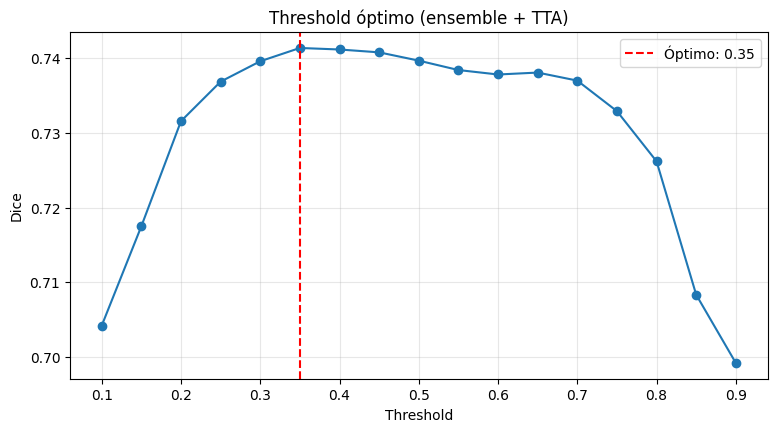

In [21]:
# ============================================================
# THRESHOLD ÓPTIMO DEL ENSEMBLE (con TTA) EN VALIDACIÓN
# ============================================================
def ensemble_val_probs(models, tta=True):
    probs_all, masks_all = [], []
    use_amp = USE_AMP and DEVICE.type == 'cuda'
    for m in models:
        m.eval()
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            p_sum = None
            for m in models:
                with torch.autocast('cuda', dtype=torch.float16, enabled=use_amp):
                    p = torch.sigmoid(m(images))
                    if tta:
                        p_flip = torch.flip(torch.sigmoid(m(torch.flip(images, [-1]))), [-1])
                        p = (p + p_flip) / 2.0
                p_sum = p if p_sum is None else p_sum + p
            probs_all.append((p_sum / len(models)).cpu())
            masks_all.append(masks.cpu())
    return torch.cat(probs_all), torch.cat(masks_all)

val_probs, val_masks = ensemble_val_probs(models)
print("Probabilidades del ensemble (val):", tuple(val_probs.shape))

ths = np.arange(0.1, 0.95, 0.05)
dices = [dice_score((val_probs > t).float(), val_masks).item() for t in ths]
best_threshold = ths[int(np.argmax(dices))]
print(f"Ensemble+TTA: mejor threshold {best_threshold:.2f} -> Dice val {max(dices):.4f}")

plt.figure(figsize=(9, 4.5))
plt.plot(ths, dices, marker='o')
plt.axvline(best_threshold, color='r', ls='--', label=f'Óptimo: {best_threshold:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Dice')
plt.title('Threshold óptimo (ensemble + TTA)')
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [22]:
# ============================================================
# SUBMISSION GANADORA (ensemble + TTA + best_threshold) Y SUBIDA A KAGGLE
# ============================================================
test_images = find_test_images()
results = []
use_amp = USE_AMP and DEVICE.type == 'cuda'

for img_path in test_images:
    img_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_norm = (img_norm - mean) / std
    t = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    p_sum = None
    for m in models:
        m.eval()
        with torch.no_grad():
            with torch.autocast('cuda', dtype=torch.float16, enabled=use_amp):
                p = torch.sigmoid(m(t))
                p_flip = torch.flip(torch.sigmoid(m(torch.flip(t, [-1]))), [-1])
                p = (p + p_flip) / 2.0
        p_sum = p if p_sum is None else p_sum + p

    probs = (p_sum / len(models)).float().squeeze().cpu().numpy()
    probs_resized = cv2.resize(probs, (w, h))
    mask_binary = (probs_resized > best_threshold).astype(np.uint8)
    results.append({'Id': img_path.name, 'Expected': mask_to_rle(mask_binary),
                    'Height': h, 'Width': w})

submission_winner = pd.DataFrame(results)
assert 'Id' in submission_winner.columns and len(submission_winner) > 0
n_tumor = int((submission_winner['Expected'] != '').sum())
submission_winner = align_submission(submission_winner)   # adapta al formato exacto de sample_submission.csv
submission_winner.to_csv('submission_ganadora.csv', index=False)

print(f"submission_ganadora.csv: {len(submission_winner)} filas ({n_tumor} con tumor).")

# ---- Verificación contra sample_submission ----
sample_path = DATA_DIR / 'sample_submission.csv'
if not sample_path.exists():
    cands = list(DATA_DIR.rglob('sample_submission.csv'))
    sample_path = cands[0] if cands else None
if sample_path is not None:
    sample = pd.read_csv(sample_path)
    # Limpiar BOM/CRLF de las cabeceras antes de comparar (p. ej. 'Expected\r' en CRLF)
    sample.columns = [str(c).strip().lstrip('\ufeff') for c in sample.columns]
    submission_winner.columns = [str(c).strip().lstrip('\ufeff') for c in submission_winner.columns]
    assert list(submission_winner.columns) == list(sample.columns),         f"Columnas distintas: submission={list(submission_winner.columns)} sample={list(sample.columns)}"
    assert len(submission_winner) == len(sample), "Número de filas distinto"
    # Usar la columna de Id real del sample (ImageId, Id, ...) — la submission ya está adaptada
    id_col = 'ImageId' if 'ImageId' in sample.columns else ('Id' if 'Id' in sample.columns else sample.columns[0])
    assert set(submission_winner[id_col]) == set(sample[id_col]), "Ids distintos"
    print("✔ Submission válida: mismas columnas, filas e Ids que sample_submission.csv")

# ---- Subida automática a Kaggle (opcional) ----
AUTO_SUBMIT = True
if AUTO_SUBMIT:
    import subprocess, sys
    kaggle_json = Path.home() / '.kaggle' / 'kaggle.json'
    if not kaggle_json.exists():
        kaggle_json = Path('/content/kaggle.json')
    if kaggle_json.exists():
        kdir = Path.home() / '.kaggle'; kdir.mkdir(parents=True, exist_ok=True)
        if not (kdir / 'kaggle.json').exists():
            shutil.copy(kaggle_json, kdir / 'kaggle.json')
            os.chmod(kdir / 'kaggle.json', 0o600)
        r = subprocess.run([sys.executable, '-m', 'kaggle', 'competitions', 'submit',
                            '-c', 'upct-medical-image-segmentation-challenge-2026-27',
                            '-f', 'submission_ganadora.csv',
                            '-m', 'Ensemble U-Net ResNet34 (3 seeds) + TTA + threshold'],
                           capture_output=True, text=True)
        print((r.stdout or r.stderr)[-1200:])
        print("Subida enviada. Revisa el Leaderboard en Kaggle (My Submissions).")
    else:
        print("No hay kaggle.json accesible: sube 'submission_ganadora.csv' manualmente en Kaggle.")


submission_ganadora.csv: 234 filas (191 con tumor).
✔ Submission válida: mismas columnas, filas e Ids que sample_submission.csv
No hay kaggle.json accesible: sube 'submission_ganadora.csv' manualmente en Kaggle.
